# TEE User Study Analysis
Carolina Carreira, McKenna McCall

This notebook contains code for performing most of the basic, descriptive analysis and for creating the tables and figures for the paper. It pulls from the full, anonymized CSV file from the survey.

# Setup

In [4658]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import surveyfields
import numpy as np

pd.set_option('display.width', 400)
pd.set_option('display.max_columns', 10)
pd.set_option('display.min_rows', 40)

sns.set_theme()

ENCODING = 'utf-8-sig'
RESPONSE_ID = "ResponseId"
EXPORT_DIR = "./export/"
PATH_EXCLUSION = EXPORT_DIR+"exclusions.csv"
PATH_DEMOGRAPHIC_QUAL = EXPORT_DIR+"demographic-recoded.csv"
PATH_WILLINGNESS = EXPORT_DIR+"willingness-recoded.csv"
PATH_QUALITATIVE = EXPORT_DIR+"qualitative_data.csv"

### Read data and some basic cleaning

* Read scored data
* Re-label data

In [4659]:
# Read data, drop unnecessary qualtrics columns
results = pd.read_csv('./export/anonymized_data.csv', encoding=ENCODING)
results.columns = surveyfields.allFields

### Recode fields for regressions

This block recodes several of the background/experience fields into more
condensed versions more suitable for running regression analyses.
* Reduce number of levels in age, education, and gender
* Convert demographic specific things to True and False booleans (e.g., IoT device ownership)

In [4660]:
def recode_for_regression(df):

  # Recode age into 10 year buckets
  ageMap = {
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55+',
    '65+ years old': '55+',
    'Prefer not to say': 'Prefer not to say'
  }
  df['age_reduced'] = df['age'].apply(lambda age: ageMap[age])


  # Recode education into two buckets
  educationMap = {
    'Associates or technical degree': 'Bachelor or associate degree',
    'Bachelor’s degree': 'Bachelor or associate degree',
    'Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS etc.)': 'Graduate degree',
    'High school diploma or GED': 'High school or equivalent',
    'Some high school or less': 'Have not completed high school',
    'Other': 'Other',
    'Some college, but no degree': 'High school or equivalent',
    'Prefer not to say': 'Prefer not to say'
  }
  df['education_reduced'] = df['education'].apply(lambda edu: educationMap[edu])

  # Recode Medical Job to True or False
  medicalExpMap = {
    'Yes; as a participant': True,
    'Yes; as a researcher': True,
    'Yes, as a participant': True, # follow-up only
    'Yes, as a researcher': True, # follow-up only
    'No': False,
    'I’m not sure/Other': False
  }
  df['previous_medical_research'] = df['demo-medical'].apply(lambda x: medicalExpMap[x])

  # Recode Medical Experience to True or False
  medicalJobMap = {
    'Yes': True,
    'No, but I have been in the past': True,
    'No': False,
    'I’m not sure/Other': False
  }
  df['medical_job'] = df['demo-medical-employ'].apply(lambda x: medicalJobMap[x])

  # Recode ownership of IoT to True or False
  IoTMap = {
    'Yes, and I use the smart features': True,
    'Yes, but I don’t use the smart features': True,
    'No': False,
    "No, but I have in the past": True,
    'I’m not sure/Other': False
  }
  df['IoT_ownership'] = df['demo-iot'].apply(lambda x: IoTMap[x])

  # Recode IoT automation to True or False
  IoTMap = {
    'Yes, I currently use home automation': True,
    'Yes, I have used home automation, but not currently': True,
    'No, I don’t own smart devices': False,
    "No, I do not use home automation, but I do own smart devices": False,
    'I’m not sure/Other': False
  }
  df['IoT_automation'] = df['demo-tap'].apply(lambda x: IoTMap[x])

  # Recode employment in IT field
  TechMap = {
    "Yes": True,
    "No": False,
    "No, but I have been in the past": True,
    "I’m not sure/Other": False
  }
  df['CS_Employment'] = df['demo-cs-employ'].apply(lambda x: TechMap[x])

  # Recode education in CS 
  TechMap = {
    "Yes": True,
    "No": False,
    "I'm not sure/Other": False
  }
  df['CS_Education'] = df['demo-cs-education'].apply(lambda x: TechMap[x])
  
  return df

In [4661]:
results = recode_for_regression(results)

# Participant demographics

Counts for the number of participants in each demographic/experience category
of interest.

We can use `df.to_latex()` on each of these tables, and then copy and paste them into
one big demographics table for the paper.

In [4662]:
def demo_table(column):
  s1 = results[column].value_counts().rename('Count')
  s1c = (100 * s1 / s1.sum()).rename('Percent')
  s1 = pd.DataFrame(s1)
  s1c = pd.DataFrame(s1c)
  
  return s1.join(s1c).fillna(0).astype({'Count': 'Int64'})
  #return s1.join(s1c).join(s2, how='outer').join(s2c).fillna(0).astype({'S2 Count': 'Int64', 'S1 Count': 'Int64'})

In [4663]:
print(demo_table('gender').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
Male & 229 & 48.8 \\
Female & 228 & 48.6 \\
Non-binary / third gender & 11 & 2.3 \\
Prefer not to say & 1 & 0.2 \\
\end{tabular}


In [4664]:
print(demo_table('age_reduced').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
25-34 & 151 & 32.2 \\
35-44 & 119 & 25.4 \\
18-24 & 74 & 15.8 \\
45-54 & 63 & 13.4 \\
55+ & 62 & 13.2 \\
\end{tabular}


In [4665]:
print(demo_table('education_reduced').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
Bachelor or associate degree & 207 & 44.1 \\
High school or equivalent & 161 & 34.3 \\
Graduate degree & 90 & 19.2 \\
Have not completed high school & 9 & 1.9 \\
Prefer not to say & 2 & 0.4 \\
\end{tabular}


In [4666]:
print(demo_table('demo-tee').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
No & 434 & 92.5 \\
Yes & 35 & 7.5 \\
\end{tabular}


In [4667]:
print(demo_table('CS_Employment').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
False & 391 & 83.4 \\
True & 78 & 16.6 \\
\end{tabular}


In [4668]:
print(demo_table('CS_Education').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
False & 410 & 87.4 \\
True & 59 & 12.6 \\
\end{tabular}


In [4669]:
results['demo_CS'] = pd.DataFrame(results[['CS_Employment','CS_Education']]).any(axis=1)
print(demo_table('demo_CS').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
False & 374 & 79.7 \\
True & 95 & 20.3 \\
\end{tabular}


In [4670]:
print(demo_table('IoT_ownership').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
True & 380 & 81.0 \\
False & 89 & 19.0 \\
\end{tabular}


In [4671]:
print(demo_table('IoT_automation').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
False & 309 & 65.9 \\
True & 160 & 34.1 \\
\end{tabular}


In [4672]:
results['demo_IoT'] = pd.DataFrame(results[['IoT_ownership','IoT_automation']]).any(axis=1)
print(demo_table('demo_IoT').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
True & 382 & 81.4 \\
False & 87 & 18.6 \\
\end{tabular}


In [4673]:
print(demo_table('previous_medical_research').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
False & 390 & 83.2 \\
True & 79 & 16.8 \\
\end{tabular}


In [4674]:
print(demo_table('medical_job').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
False & 410 & 87.4 \\
True & 59 & 12.6 \\
\end{tabular}


In [4675]:
results['demo_Medical'] = pd.DataFrame(results[['previous_medical_research','medical_job']]).any(axis=1)
print(demo_table('demo_Medical').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
False & 356 & 75.9 \\
True & 113 & 24.1 \\
\end{tabular}


In [4676]:
# exclude_from_export = [
#     'A3', 'A156', 'A198', 'A206', 'A258',
#     'B5', 'B53', 'B54', 'B80', 'B102'
# ]

In [4677]:
demographics_export = results[['id', 'gender', 'age_reduced', 'education_reduced', 'previous_medical_research', 'medical_job', 'IoT_ownership', 'IoT_automation']].copy()


#demographics_export = demographics_export[~demographics_export['id'].isin(exclude_from_export)]
demographics_export.rename(columns={
    'age_reduced': 'age',
    'education_reduced': 'education'
}, inplace=True)

demographics_export.to_csv('./export/demographics.csv', index=False)

# Scores Analysis

We already have count correct per question (0 or 1)
And here are doing: 
- Count correct per scenario (0 to 10)
- Count correct overall (0 to 20)


In [4678]:
results_columns_M = ["M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "M10"]
results_columns_I = ["I1", "I2", "I3", "I4", "I5", "I6", "I7", "I8", "I9", "I10"]   
    
column_sum_score_medical = "sum_score_medical"
column_sum_score_IoT = "sum_score_IoT"
column_overall_score_participant = "overall_score"

def recode_for_scores(df):
  
  # Count correct per scenario (0 to 8)
  df[column_sum_score_medical] = 0
  for col in results_columns_M:
    df[column_sum_score_medical] +=  df[col]

  # Count correct per scenario (0 to 8)
  df[column_sum_score_IoT] = 0
  for col in results_columns_I:
    df[column_sum_score_IoT] +=  df[col]

  # Count correct overall (0 to 16)
  df[column_overall_score_participant] = 0
  for col in results_columns_M:
    df[column_overall_score_participant] +=  df[col]
  for col in results_columns_I:
    df[column_overall_score_participant] +=  df[col]

  return df

results = recode_for_scores(results)

scores_export = results[['id',column_sum_score_medical,column_sum_score_IoT, column_overall_score_participant] + results_columns_M+results_columns_I+["SCENARIO_Med", "SCENARIO_IoT"]].copy()

scores_export.to_csv('./export/scores.csv', index=False)


## Summarize scores
* Overall mean score, per question
* Overall mean score, per question, per scenario
* Overall mean score, per question, per TEE explanation
TO-DO:
* Confidence answers were correct

In [4679]:
medical_scores_results = results[surveyfields.medicalScoreFields]
medical_scores_results.columns = ["Scenario", "S1", "S2", "S3", "Q1","Q2","Q3","Q4","Q5","Q6","Q7","Q8","Q9","Q10"]

iot_scores_results = results[surveyfields.iotScoreFields]
iot_scores_results.columns = ["Scenario", "S1", "S2", "S3", "Q1","Q2","Q3","Q4","Q5","Q6","Q7","Q8","Q9","Q10"]

In [4680]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario","S1","S2","S3"],axis=1),
                        iot_scores_results.drop(["Scenario","S1","S2","S3"],axis=1)],axis=0)

overall_scores_counts = overall_scores.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(overall_scores_counts.loc[1.0].rename("Overall"))
all_scores = all_scores / len(overall_scores)

print(all_scores.style.format('{:.1%}').to_latex())

\begin{tabular}{lr}
 & Overall \\
Q1 & 96.7% \\
Q2 & 91.9% \\
Q3 & 79.0% \\
Q4 & 80.9% \\
Q5 & 87.2% \\
Q6 & 82.0% \\
Q7 & 69.8% \\
Q8 & 61.1% \\
Q9 & 84.2% \\
Q10 & 57.2% \\
\end{tabular}


Comparing Survey 1 and 2 results

In [4681]:
resultsF = pd.read_csv('./export_followup/anonymized_data.csv', encoding=ENCODING)

resultsF_columns_M = ["SCENARIO_Med", "EXPLN", "FAQ", "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "M10", "M11", "M12"]
resultsF_columns_I = ["SCENARIO_IoT", "EXPLN", "FAQ", "I1", "I2", "I3", "I4", "I5", "I6", "I7", "I8", "I9", "I10", "I11", "I12"]   

medical_scores_followup_results = resultsF[resultsF_columns_M]
medical_scores_followup_results.columns = ["Scenario", "Expln", "FAQ", "Q1","Q2","Q3","Q4","Q5","Q6","Q7","Q8","Q9","Q10", "Q11", "Q12"]
iot_scores_followup_results = resultsF[resultsF_columns_I]
iot_scores_followup_results.columns = ["Scenario", "Expln", "FAQ", "Q1","Q2","Q3","Q4","Q5","Q6","Q7","Q8","Q9","Q10","Q11","Q12"]

overall_scoresF = pd.concat([medical_scores_followup_results.drop(["Scenario", "Expln", "FAQ"],axis=1),
                        iot_scores_followup_results.drop(["Scenario", "Expln", "FAQ"],axis=1)],axis=0)

overall_scoresF_counts = overall_scoresF.apply(lambda col: col.value_counts())

all_scoresF = pd.DataFrame(overall_scoresF_counts.loc[1.0].rename("Overall"))
all_scoresF = all_scoresF / len(overall_scoresF)

Text(0, 0.5, '')

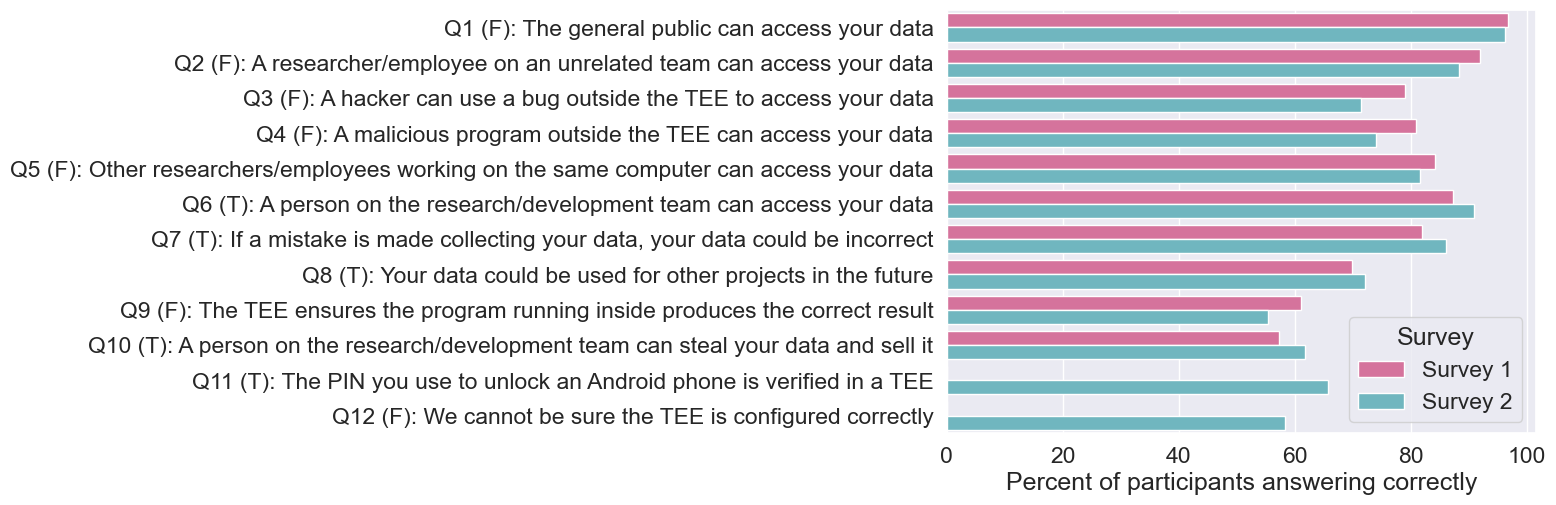

In [4682]:
scores = (all_scores*100).reset_index(names=["Question"])
scoresF = (all_scoresF*100).reset_index(names=["Question"])

##re-number Q9 as Q5 in survey 1
row = scores.loc[scores["Question"]=="Q9"]
columns = scores.columns
scores.drop(row.index, inplace=True)
scores = pd.DataFrame(np.insert(scores.values, 4, values=row, axis=0))
scores.columns = columns
##add empty Q11 Q12 to survey 1
scores = pd.concat([scores, pd.DataFrame({'Question':["Q11","Q12"],'Overall':[0,0]})])

##re-number Q9 as Q5 in survey 2
row = scoresF.loc[scoresF["Question"]=="Q9"]
columns = scoresF.columns
scoresF.drop(row.index, inplace=True)
scoresF = pd.DataFrame(np.insert(scoresF.values, 4, values=row, axis=0))
scoresF.columns = columns

##overall scores
scores["Survey"] = ["Survey 1"]*12
scoresF["Survey"] = ["Survey 2"]*12

scores_overall = pd.concat([scores,scoresF])

scores_overall.replace("Q1","Q1 (F): The general public can access your data", inplace=True)
scores_overall.replace("Q2","Q2 (F): A researcher/employee on an unrelated team can access your data", inplace=True)
scores_overall.replace("Q3","Q3 (F): A hacker can use a bug outside the TEE to access your data", inplace=True)
scores_overall.replace("Q4","Q4 (F): A malicious program outside the TEE can access your data", inplace=True)
scores_overall.replace("Q9","Q5 (F): Other researchers/employees working on the same computer can access your data", inplace=True)
scores_overall.replace("Q5","Q6 (T): A person on the research/development team can access your data", inplace=True)
scores_overall.replace("Q6","Q7 (T): If a mistake is made collecting your data, your data could be incorrect", inplace=True)
scores_overall.replace("Q7","Q8 (T): Your data could be used for other projects in the future", inplace=True)
scores_overall.replace("Q8","Q9 (F): The TEE ensures the program running inside produces the correct result", inplace=True)
scores_overall.replace("Q10","Q10 (T): A person on the research/development team can steal your data and sell it", inplace=True)
scores_overall.replace("Q11","Q11 (T): The PIN you use to unlock an Android phone is verified in a TEE", inplace=True)
scores_overall.replace("Q12","Q12 (F): We cannot be sure the TEE is configured correctly", inplace=True)

sns.set(font_scale=1.5)
sns.set_palette(['#E56399','#63C0CC','#68A357','#BD9EB9','#ECAA69','#ABABAB'], n_colors=6)
fig, ax = plt.subplots(figsize=(7.6, 5.5))
ax = sns.barplot(data=scores_overall, x="Overall", y="Question", hue="Survey", ax=ax)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.83, 0), ncol=1)
ax.set_xlabel('Percent of participants answering correctly')
ax.set_ylabel('')

Text(0, 0.5, '')

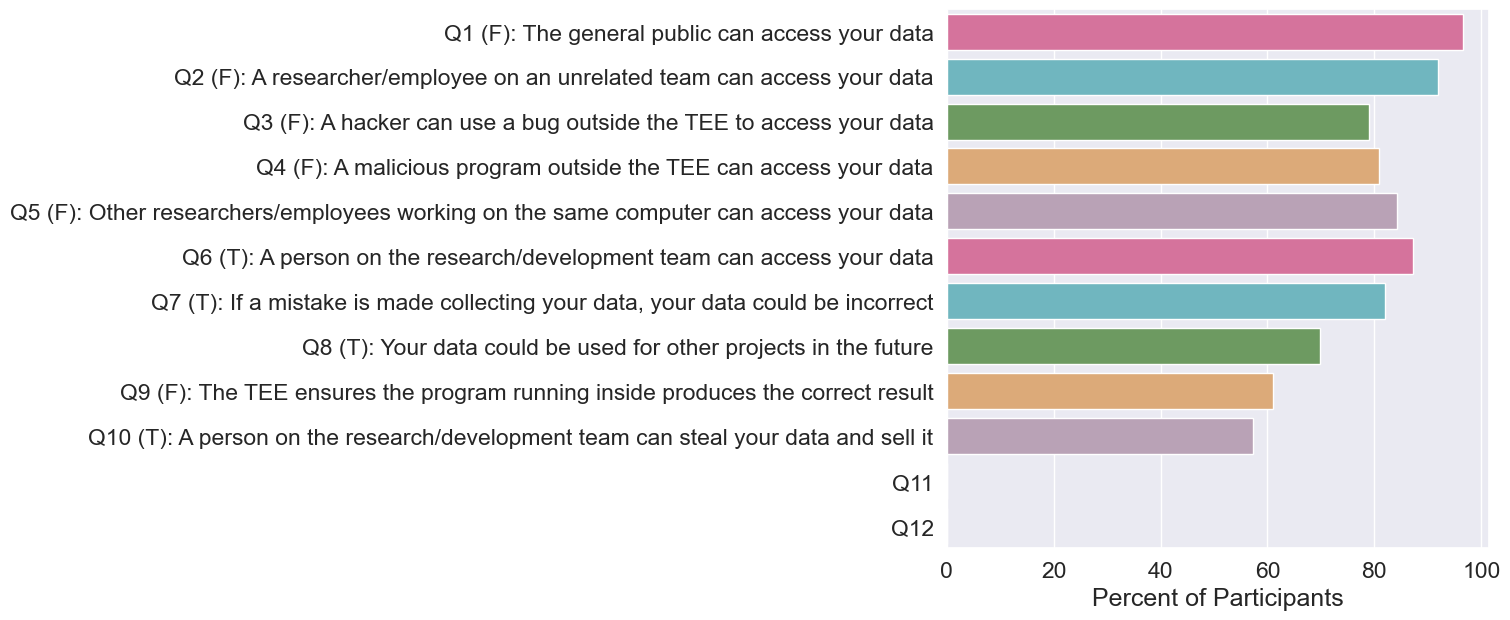

In [4683]:
scores = (all_scores*100).reset_index(names=["Question"])
scores.rename(columns={"Overall":"Survey 1"}, inplace=True)

##re-number Q9 as Q5
row = scores.loc[scores["Question"]=="Q9"]
columns = scores.columns
scores.drop(row.index, inplace=True)
scores = pd.DataFrame(np.insert(scores.values, 4, values=row, axis=0))
scores.columns = columns
scores = pd.concat([scores, pd.DataFrame({'Question':["Q11","Q12"],'Survey 1':[0,0]})])

scores.replace("Q1","Q1 (F): The general public can access your data", inplace=True)
scores.replace("Q2","Q2 (F): A researcher/employee on an unrelated team can access your data", inplace=True)
scores.replace("Q3","Q3 (F): A hacker can use a bug outside the TEE to access your data", inplace=True)
scores.replace("Q4","Q4 (F): A malicious program outside the TEE can access your data", inplace=True)
scores.replace("Q9","Q5 (F): Other researchers/employees working on the same computer can access your data", inplace=True)
scores.replace("Q5","Q6 (T): A person on the research/development team can access your data", inplace=True)
scores.replace("Q6","Q7 (T): If a mistake is made collecting your data, your data could be incorrect", inplace=True)
scores.replace("Q7","Q8 (T): Your data could be used for other projects in the future", inplace=True)
scores.replace("Q8","Q9 (F): The TEE ensures the program running inside produces the correct result", inplace=True)
scores.replace("Q10","Q10 (T): A person on the research/development team can steal your data and sell it", inplace=True)

sns.set(font_scale=1.5)
fig, ax = plt.subplots(figsize=(7, 7))
ax = sns.barplot(data=scores,x="Survey 1", y="Question", ax=ax,
    palette=['#E56399','#63C0CC','#68A357','#ECAA69','#BD9EB9'])
ax.set_xlabel('Percent of Participants')
ax.set_ylabel('')

In [4684]:
medicalC_results = medical_scores_results.loc[medical_scores_results["Scenario"] == "Medical-Complex"] \
    .drop(["Scenario","S1","S2","S3"],axis=1)
medicalS_results = medical_scores_results.loc[medical_scores_results["Scenario"] == "Medical-Simple"] \
    .drop(["Scenario","S1","S2","S3"],axis=1)
iotC_results = iot_scores_results.loc[iot_scores_results["Scenario"] == "IoT-Complex"] \
    .drop(["Scenario","S1","S2","S3"],axis=1)
iotS_results = iot_scores_results.loc[iot_scores_results["Scenario"] == "IoT-Simple"] \
    .drop(["Scenario","S1","S2","S3"],axis=1)

medicalC_score_counts = medicalC_results.apply(lambda col: col.value_counts())
medicalS_score_counts = medicalS_results.apply(lambda col: col.value_counts())
iotC_score_counts = iotC_results.apply(lambda col: col.value_counts())
iotS_score_counts = iotS_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(medicalC_score_counts.loc[1.0].rename("Medical Complex")) \
    .join(pd.DataFrame(medicalS_score_counts.loc[1.0].rename("Medical Simple"))) \
    .join(pd.DataFrame(iotC_score_counts.loc[1.0].rename("IoT Complex"))) \
    .join(pd.DataFrame(iotS_score_counts.loc[1.0].rename("IoT Simple")))

all_scores["Medical Complex"] = all_scores["Medical Complex"] / len(medicalC_results)
all_scores["Medical Simple"] = all_scores["Medical Simple"] / len(medicalS_results)
all_scores["IoT Complex"] = all_scores["IoT Complex"] / len(iotC_results)
all_scores["IoT Simple"] = all_scores["IoT Simple"] / len(iotS_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format(lambda s: '{:.1f}\%'.format(s*100)).to_latex())

\begin{tabular}{lrrrr}
 & Medical Complex & Medical Simple & IoT Complex & IoT Simple \\
Q1 & 96.2\% & 97.0\% & 96.6\% & 97.0\% \\
Q2 & 92.4\% & 93.1\% & 90.6\% & 91.5\% \\
Q3 & 80.9\% & 76.8\% & 78.1\% & 80.1\% \\
Q4 & 83.1\% & 81.5\% & 80.7\% & 78.4\% \\
Q5 & 91.1\% & 87.6\% & 83.3\% & 86.9\% \\
Q6 & 86.9\% & 80.3\% & 82.0\% & 78.8\% \\
Q7 & 87.3\% & 63.1\% & 66.1\% & 62.7\% \\
Q8 & 82.2\% & 57.1\% & 54.1\% & 50.8\% \\
Q9 & 83.5\% & 84.1\% & 87.1\% & 82.2\% \\
Q10 & 59.3\% & 55.4\% & 61.4\% & 53.0\% \\
mean & 84.3\% & 77.6\% & 78.0\% & 76.1\% \\
\end{tabular}


In [4685]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario"],axis=1),
                        iot_scores_results.drop(["Scenario"],axis=1)],axis=0)

hw_results = overall_scores.loc[overall_scores["S1"] == "Hardware"] \
        .drop(["S1","S2","S3"],axis=1)
trust_results = overall_scores.loc[overall_scores["S1"] == "Trust"] \
        .drop(["S1","S2","S3"],axis=1)
unsub_results = overall_scores.loc[overall_scores["S1"] == "Unsubstantial"] \
        .drop(["S1","S2","S3"],axis=1)
tech_results = overall_scores.loc[overall_scores["S2"] == "Technical"] \
        .drop(["S1","S2","S3"],axis=1)
untech_results = overall_scores.loc[overall_scores["S2"] == "Untechnical"] \
        .drop(["S1","S2","S3"],axis=1)
prevent_results = overall_scores.loc[overall_scores["S3"] == "Prevents"] \
        .drop(["S1","S2","S3"],axis=1)
noPrevent_results = overall_scores.loc[overall_scores["S3"] == "No Prevents"] \
        .drop(["S1","S2","S3"],axis=1)

hw_score_counts = hw_results.apply(lambda col: col.value_counts())
trust_score_counts = trust_results.apply(lambda col: col.value_counts())
unsub_score_counts = unsub_results.apply(lambda col: col.value_counts())
tech_score_counts = tech_results.apply(lambda col: col.value_counts())
untech_score_counts = untech_results.apply(lambda col: col.value_counts())
prevent_score_counts = prevent_results.apply(lambda col: col.value_counts())
noPrevent_score_counts = noPrevent_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(hw_score_counts.loc[1.0].rename("Hardware")) \
    .join(pd.DataFrame(trust_score_counts.loc[1.0].rename("Trust"))) \
    .join(pd.DataFrame(unsub_score_counts.loc[1.0].rename("Unsubstantial"))) \
    .join(pd.DataFrame(tech_score_counts.loc[1.0].rename("Technical"))) \
    .join(pd.DataFrame(untech_score_counts.loc[1.0].rename("Untechnical"))) \
    .join(pd.DataFrame(prevent_score_counts.loc[1.0].rename("Prevents"))) \
    .join(pd.DataFrame(noPrevent_score_counts.loc[1.0].rename("No Prevents")))

all_scores["Hardware"] = all_scores["Hardware"] / len(hw_results)
all_scores["Trust"] = all_scores["Trust"] / len(trust_results)
all_scores["Unsubstantial"] = all_scores["Unsubstantial"] / len(unsub_results)
all_scores["Technical"] = all_scores["Technical"] / len(tech_results)
all_scores["Untechnical"] = all_scores["Untechnical"] / len(untech_results)
all_scores["Prevents"] = all_scores["Prevents"] / len(prevent_results)
all_scores["No Prevents"] = all_scores["No Prevents"] / len(noPrevent_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format(lambda s: '{:.1f}\%'.format(s*100)).to_latex())


\begin{tabular}{lrrrrrrr}
 & Hardware & Trust & Unsubstantial & Technical & Untechnical & Prevents & No Prevents \\
Q1 & 97.8\% & 94.5\% & 97.8\% & 96.6\% & 96.8\% & 95.7\% & 97.7\% \\
Q2 & 94.0\% & 87.7\% & 93.9\% & 88.7\% & 95.1\% & 91.5\% & 92.3\% \\
Q3 & 78.6\% & 81.8\% & 76.6\% & 78.4\% & 79.6\% & 82.5\% & 75.5\% \\
Q4 & 80.5\% & 80.8\% & 81.4\% & 82.7\% & 79.1\% & 87.8\% & 74.0\% \\
Q5 & 88.1\% & 87.3\% & 86.2\% & 86.1\% & 88.3\% & 87.2\% & 87.2\% \\
Q6 & 79.6\% & 82.8\% & 83.7\% & 84.0\% & 80.0\% & 81.6\% & 82.3\% \\
Q7 & 67.9\% & 73.7\% & 67.9\% & 69.2\% & 70.4\% & 71.2\% & 68.5\% \\
Q8 & 56.9\% & 60.1\% & 66.3\% & 62.8\% & 59.4\% & 60.5\% & 61.7\% \\
Q9 & 84.6\% & 82.5\% & 85.6\% & 82.9\% & 85.5\% & 85.9\% & 82.6\% \\
Q10 & 57.5\% & 58.1\% & 56.1\% & 53.0\% & 61.5\% & 53.8\% & 60.6\% \\
mean & 78.6\% & 78.9\% & 79.6\% & 78.4\% & 79.6\% & 79.8\% & 78.3\% \\
\end{tabular}


In [4686]:
med_hw_results = medical_scores_results.loc[medical_scores_results["S1"] == "Hardware"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
med_trust_results = medical_scores_results.loc[medical_scores_results["S1"] == "Trust"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
med_unsub_results = medical_scores_results.loc[medical_scores_results["S1"] == "Unsubstantial"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
med_tech_results = medical_scores_results.loc[medical_scores_results["S2"] == "Technical"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
med_untech_results = medical_scores_results.loc[medical_scores_results["S2"] == "Untechnical"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
med_prevent_results = medical_scores_results.loc[medical_scores_results["S3"] == "Prevents"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
med_noPrevent_results = medical_scores_results.loc[medical_scores_results["S3"] == "No Prevents"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
iot_hw_results = iot_scores_results.loc[iot_scores_results["S1"] == "Hardware"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
iot_trust_results = iot_scores_results.loc[iot_scores_results["S1"] == "Trust"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
iot_unsub_results = iot_scores_results.loc[iot_scores_results["S1"] == "Unsubstantial"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
iot_tech_results = iot_scores_results.loc[iot_scores_results["S2"] == "Technical"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
iot_untech_results = iot_scores_results.loc[iot_scores_results["S2"] == "Untechnical"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
iot_prevent_results = iot_scores_results.loc[iot_scores_results["S3"] == "Prevents"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)
iot_noPrevent_results = iot_scores_results.loc[iot_scores_results["S3"] == "No Prevents"] \
        .drop(["Scenario","S1","S2","S3"],axis=1)

med_hw_score_counts = med_hw_results.apply(lambda col: col.value_counts())
med_trust_score_counts = med_trust_results.apply(lambda col: col.value_counts())
med_unsub_score_counts = med_unsub_results.apply(lambda col: col.value_counts())
med_tech_score_counts = med_tech_results.apply(lambda col: col.value_counts())
med_untech_score_counts = med_untech_results.apply(lambda col: col.value_counts())
med_prevent_score_counts = med_prevent_results.apply(lambda col: col.value_counts())
med_noPrevent_score_counts = med_noPrevent_results.apply(lambda col: col.value_counts())
iot_hw_score_counts = iot_hw_results.apply(lambda col: col.value_counts())
iot_trust_score_counts = iot_trust_results.apply(lambda col: col.value_counts())
iot_unsub_score_counts = iot_unsub_results.apply(lambda col: col.value_counts())
iot_tech_score_counts = iot_tech_results.apply(lambda col: col.value_counts())
iot_untech_score_counts = iot_untech_results.apply(lambda col: col.value_counts())
iot_prevent_score_counts = iot_prevent_results.apply(lambda col: col.value_counts())
iot_noPrevent_score_counts = iot_noPrevent_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(med_hw_score_counts.loc[1.0].rename("Med Hardware")) \
    .join(pd.DataFrame(iot_hw_score_counts.loc[1.0].rename("IoT Hardware"))) \
    .join(pd.DataFrame(med_trust_score_counts.loc[1.0].rename("Med Trust"))) \
    .join(pd.DataFrame(iot_trust_score_counts.loc[1.0].rename("IoT Trust"))) \
    .join(pd.DataFrame(med_unsub_score_counts.loc[1.0].rename("Med Unsubstantial"))) \
    .join(pd.DataFrame(iot_unsub_score_counts.loc[1.0].rename("IoT Unsubstantial"))) \
    .join(pd.DataFrame(med_tech_score_counts.loc[1.0].rename("Med Technical"))) \
    .join(pd.DataFrame(iot_tech_score_counts.loc[1.0].rename("IoT Technical"))) \
    .join(pd.DataFrame(med_untech_score_counts.loc[1.0].rename("Med Untechnical"))) \
    .join(pd.DataFrame(iot_untech_score_counts.loc[1.0].rename("IoT Untechnical"))) \
    .join(pd.DataFrame(med_prevent_score_counts.loc[1.0].rename("Med Prevents"))) \
    .join(pd.DataFrame(iot_prevent_score_counts.loc[1.0].rename("IoT Prevents"))) \
    .join(pd.DataFrame(med_noPrevent_score_counts.loc[1.0].rename("Med No Prevents"))) \
    .join(pd.DataFrame(iot_noPrevent_score_counts.loc[1.0].rename("IoT No Prevents")))

all_scores["Med Hardware"] = all_scores["Med Hardware"] / len(med_hw_results)
all_scores["Med Trust"] = all_scores["Med Trust"] / len(med_trust_results)
all_scores["Med Unsubstantial"] = all_scores["Med Unsubstantial"] / len(med_unsub_results)
all_scores["Med Technical"] = all_scores["Med Technical"] / len(med_tech_results)
all_scores["Med Untechnical"] = all_scores["Med Untechnical"] / len(med_untech_results)
all_scores["Med Prevents"] = all_scores["Med Prevents"] / len(med_prevent_results)
all_scores["Med No Prevents"] = all_scores["Med No Prevents"] / len(med_noPrevent_results)
all_scores["IoT Hardware"] = all_scores["IoT Hardware"] / len(iot_hw_results)
all_scores["IoT Trust"] = all_scores["IoT Trust"] / len(iot_trust_results)
all_scores["IoT Unsubstantial"] = all_scores["IoT Unsubstantial"] / len(iot_unsub_results)
all_scores["IoT Technical"] = all_scores["IoT Technical"] / len(iot_tech_results)
all_scores["IoT Untechnical"] = all_scores["IoT Untechnical"] / len(iot_untech_results)
all_scores["IoT Prevents"] = all_scores["IoT Prevents"] / len(iot_prevent_results)
all_scores["IoT No Prevents"] = all_scores["IoT No Prevents"] / len(iot_noPrevent_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format('{:.1%}').to_latex())


\begin{tabular}{lrrrrrrrrrrrrrr}
 & Med Hardware & IoT Hardware & Med Trust & IoT Trust & Med Unsubstantial & IoT Unsubstantial & Med Technical & IoT Technical & Med Untechnical & IoT Untechnical & Med Prevents & IoT Prevents & Med No Prevents & IoT No Prevents \\
Q1 & 98.1% & 97.5% & 94.2% & 94.8% & 97.4% & 98.1% & 96.6% & 96.6% & 96.6% & 97.0% & 95.7% & 95.7% & 97.4% & 97.9% \\
Q2 & 95.6% & 92.5% & 88.3% & 87.0% & 94.2% & 93.6% & 89.3% & 88.0% & 96.2% & 94.0% & 91.0% & 91.9% & 94.5% & 90.2% \\
Q3 & 79.2% & 78.0% & 81.2% & 82.5% & 76.3% & 76.9% & 79.1% & 77.8% & 78.7% & 80.4% & 83.8% & 81.2% & 74.0% & 77.0% \\
Q4 & 82.4% & 78.6% & 81.8% & 79.9% & 82.7% & 80.1% & 83.8% & 81.6% & 80.9% & 77.4% & 90.2% & 85.5% & 74.5% & 73.6% \\
Q5 & 91.2% & 84.9% & 90.3% & 84.4% & 86.5% & 85.9% & 88.0% & 84.2% & 90.6% & 86.0% & 88.9% & 85.5% & 89.8% & 84.7% \\
Q6 & 81.1% & 78.0% & 85.1% & 80.5% & 84.6% & 82.7% & 85.5% & 82.5% & 81.7% & 78.3% & 84.2% & 79.1% & 83.0% & 81.7% \\
Q7 & 74.2% & 61.6% & 79.2% 

Capabilities of TEE only

In [4687]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario","Q5","Q6","Q7","Q8","Q10"],axis=1),
                        iot_scores_results.drop(["Scenario","Q5","Q6","Q7","Q8","Q10"],axis=1)],axis=0)

hw_results = overall_scores.loc[overall_scores["S1"] == "Hardware"] \
        .drop(["S1","S2","S3"],axis=1)
trust_results = overall_scores.loc[overall_scores["S1"] == "Trust"] \
        .drop(["S1","S2","S3"],axis=1)
unsub_results = overall_scores.loc[overall_scores["S1"] == "Unsubstantial"] \
        .drop(["S1","S2","S3"],axis=1)
tech_results = overall_scores.loc[overall_scores["S2"] == "Technical"] \
        .drop(["S1","S2","S3"],axis=1)
untech_results = overall_scores.loc[overall_scores["S2"] == "Untechnical"] \
        .drop(["S1","S2","S3"],axis=1)
prevent_results = overall_scores.loc[overall_scores["S3"] == "Prevents"] \
        .drop(["S1","S2","S3"],axis=1)
noPrevent_results = overall_scores.loc[overall_scores["S3"] == "No Prevents"] \
        .drop(["S1","S2","S3"],axis=1)

hw_score_counts = hw_results.apply(lambda col: col.value_counts())
trust_score_counts = trust_results.apply(lambda col: col.value_counts())
unsub_score_counts = unsub_results.apply(lambda col: col.value_counts())
tech_score_counts = tech_results.apply(lambda col: col.value_counts())
untech_score_counts = untech_results.apply(lambda col: col.value_counts())
prevent_score_counts = prevent_results.apply(lambda col: col.value_counts())
noPrevent_score_counts = noPrevent_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(hw_score_counts.loc[1.0].rename("Hardware")) \
    .join(pd.DataFrame(trust_score_counts.loc[1.0].rename("Trust"))) \
    .join(pd.DataFrame(unsub_score_counts.loc[1.0].rename("Unsubstantial"))) \
    .join(pd.DataFrame(tech_score_counts.loc[1.0].rename("Technical"))) \
    .join(pd.DataFrame(untech_score_counts.loc[1.0].rename("Untechnical"))) \
    .join(pd.DataFrame(prevent_score_counts.loc[1.0].rename("Prevents"))) \
    .join(pd.DataFrame(noPrevent_score_counts.loc[1.0].rename("No Prevents")))

all_scores["Hardware"] = all_scores["Hardware"] / len(hw_results)
all_scores["Trust"] = all_scores["Trust"] / len(trust_results)
all_scores["Unsubstantial"] = all_scores["Unsubstantial"] / len(unsub_results)
all_scores["Technical"] = all_scores["Technical"] / len(tech_results)
all_scores["Untechnical"] = all_scores["Untechnical"] / len(untech_results)
all_scores["Prevents"] = all_scores["Prevents"] / len(prevent_results)
all_scores["No Prevents"] = all_scores["No Prevents"] / len(noPrevent_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format('{:.1%}').to_latex())


\begin{tabular}{lrrrrrrr}
 & Hardware & Trust & Unsubstantial & Technical & Untechnical & Prevents & No Prevents \\
Q1 & 97.8% & 94.5% & 97.8% & 96.6% & 96.8% & 95.7% & 97.7% \\
Q2 & 94.0% & 87.7% & 93.9% & 88.7% & 95.1% & 91.5% & 92.3% \\
Q3 & 78.6% & 81.8% & 76.6% & 78.4% & 79.6% & 82.5% & 75.5% \\
Q4 & 80.5% & 80.8% & 81.4% & 82.7% & 79.1% & 87.8% & 74.0% \\
Q9 & 84.6% & 82.5% & 85.6% & 82.9% & 85.5% & 85.9% & 82.6% \\
mean & 87.1% & 85.5% & 87.1% & 85.9% & 87.2% & 88.7% & 84.4% \\
\end{tabular}


Limitations of TEE only

In [4688]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario","Q1","Q2","Q3","Q4","Q9"],axis=1),
                        iot_scores_results.drop(["Scenario","Q1","Q2","Q3","Q4","Q9"],axis=1)],axis=0)

hw_results = overall_scores.loc[overall_scores["S1"] == "Hardware"] \
        .drop(["S1","S2","S3"],axis=1)
trust_results = overall_scores.loc[overall_scores["S1"] == "Trust"] \
        .drop(["S1","S2","S3"],axis=1)
unsub_results = overall_scores.loc[overall_scores["S1"] == "Unsubstantial"] \
        .drop(["S1","S2","S3"],axis=1)
tech_results = overall_scores.loc[overall_scores["S2"] == "Technical"] \
        .drop(["S1","S2","S3"],axis=1)
untech_results = overall_scores.loc[overall_scores["S2"] == "Untechnical"] \
        .drop(["S1","S2","S3"],axis=1)
prevent_results = overall_scores.loc[overall_scores["S3"] == "Prevents"] \
        .drop(["S1","S2","S3"],axis=1)
noPrevent_results = overall_scores.loc[overall_scores["S3"] == "No Prevents"] \
        .drop(["S1","S2","S3"],axis=1)

hw_score_counts = hw_results.apply(lambda col: col.value_counts())
trust_score_counts = trust_results.apply(lambda col: col.value_counts())
unsub_score_counts = unsub_results.apply(lambda col: col.value_counts())
tech_score_counts = tech_results.apply(lambda col: col.value_counts())
untech_score_counts = untech_results.apply(lambda col: col.value_counts())
prevent_score_counts = prevent_results.apply(lambda col: col.value_counts())
noPrevent_score_counts = noPrevent_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(hw_score_counts.loc[1.0].rename("Hardware")) \
    .join(pd.DataFrame(trust_score_counts.loc[1.0].rename("Trust"))) \
    .join(pd.DataFrame(unsub_score_counts.loc[1.0].rename("Unsubstantial"))) \
    .join(pd.DataFrame(tech_score_counts.loc[1.0].rename("Technical"))) \
    .join(pd.DataFrame(untech_score_counts.loc[1.0].rename("Untechnical"))) \
    .join(pd.DataFrame(prevent_score_counts.loc[1.0].rename("Prevents"))) \
    .join(pd.DataFrame(noPrevent_score_counts.loc[1.0].rename("No Prevents")))

all_scores["Hardware"] = all_scores["Hardware"] / len(hw_results)
all_scores["Trust"] = all_scores["Trust"] / len(trust_results)
all_scores["Unsubstantial"] = all_scores["Unsubstantial"] / len(unsub_results)
all_scores["Technical"] = all_scores["Technical"] / len(tech_results)
all_scores["Untechnical"] = all_scores["Untechnical"] / len(untech_results)
all_scores["Prevents"] = all_scores["Prevents"] / len(prevent_results)
all_scores["No Prevents"] = all_scores["No Prevents"] / len(noPrevent_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format('{:.1%}').to_latex())


\begin{tabular}{lrrrrrrr}
 & Hardware & Trust & Unsubstantial & Technical & Untechnical & Prevents & No Prevents \\
Q5 & 88.1% & 87.3% & 86.2% & 86.1% & 88.3% & 87.2% & 87.2% \\
Q6 & 79.6% & 82.8% & 83.7% & 84.0% & 80.0% & 81.6% & 82.3% \\
Q7 & 67.9% & 73.7% & 67.9% & 69.2% & 70.4% & 71.2% & 68.5% \\
Q8 & 56.9% & 60.1% & 66.3% & 62.8% & 59.4% & 60.5% & 61.7% \\
Q10 & 57.5% & 58.1% & 56.1% & 53.0% & 61.5% & 53.8% & 60.6% \\
mean & 70.0% & 72.4% & 72.1% & 71.0% & 71.9% & 70.9% & 72.1% \\
\end{tabular}


## Check for learning effect

This code create a new file with a column for the first scenario and a column for the second scenario, so we can check for a learning effect

In [4689]:
fst_scenarios_results_column = "fst_scenario"  
scd_scenarios_results_column = "snd_scenario"  
def check_for_learning_effect(df):

  for index,row in df.iterrows():
    if df.loc[index]["Med_First"] == 1:
      df.at[index, fst_scenarios_results_column] =  df.loc[index][column_sum_score_medical]
      df.at[index, scd_scenarios_results_column] =  df.loc[index][column_sum_score_IoT]

    else:
      df.at[index, fst_scenarios_results_column] =  df.loc[index][column_sum_score_IoT]
      df.at[index, scd_scenarios_results_column] =  df.loc[index][column_sum_score_medical]
      
  return df


learning_effect = check_for_learning_effect(results)

learning_effect = learning_effect[['id',fst_scenarios_results_column,scd_scenarios_results_column]].copy()

learning_effect.to_csv('./export/learning_effect.csv', index=False)

learning_effect_diff = learning_effect.apply(lambda col: col["snd_scenario"] - col["fst_scenario"], axis=1)
print(round(learning_effect_diff.mean(),3))

0.211


# Trust Analysis
* Overall proportion of responses for each point on each likert scale, per scenario
* Overall proportion of responses for each point on each likert scale, per TEE explanation

Likert scales include:
* Willingness
* Safety
* Change to willingness with questions answered


In [4690]:
medical_willingness_results = results[["SCENARIO_Med","EXPLN_S1","EXPLN_S2","EXPLN_S3","willingness-medical"]]
medical_willingness_results.columns = ["Scenario","S1","S2","S3","willingness"]

iot_willingness_results = results[["SCENARIO_IoT","EXPLN_S1","EXPLN_S2","EXPLN_S3","willingness-iot"]]
iot_willingness_results.columns = ["Scenario","S1","S2","S3","willingness"]

overall_willingness = pd.concat([medical_willingness_results.drop(["Scenario"],axis=1),
                        iot_willingness_results.drop(["Scenario"],axis=1)],axis=0)

willingness_scale = ["Definitely would","Maybe would","Would not", "Not sure (Why?)"]

In [4691]:
medicalC_results = medical_willingness_results.loc[medical_willingness_results["Scenario"] == "Medical-Complex"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)
medicalS_results = medical_willingness_results.loc[medical_willingness_results["Scenario"] == "Medical-Simple"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)
iotC_results = iot_willingness_results.loc[iot_willingness_results["Scenario"] == "IoT-Complex"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)
iotS_results = iot_willingness_results.loc[iot_willingness_results["Scenario"] == "IoT-Simple"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)

willingnessMap = {
    "Definitely would" : "Definitely would",
    "Maybe would" : "Maybe",
    "Would not" : "Would not",
    "Not sure (Why?)" : "Maybe"
}   

medicalC_results["willingness"] = medicalC_results["willingness"].map(willingnessMap)
medicalS_results["willingness"] = medicalS_results["willingness"].map(willingnessMap)
iotC_results["willingness"] = iotC_results["willingness"].map(willingnessMap)
iotS_results["willingness"] = iotS_results["willingness"].map(willingnessMap)

willingness_scale_red = ["Definitely would","Maybe","Would not"]

medicalC_willingness_counts = medicalC_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
medicalS_willingness_counts = medicalS_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
iotC_willingness_counts = iotC_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
iotS_willingness_counts = iotS_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)

all_willingness = pd.DataFrame(medicalC_willingness_counts).rename(columns={"willingness":"Medical Complex"}) \
    .join(pd.DataFrame(medicalS_willingness_counts.rename(columns={"willingness":"Medical Simple"}))) \
    .join(pd.DataFrame(iotC_willingness_counts.rename(columns={"willingness":"IoT Complex"}))) \
    .join(pd.DataFrame(iotS_willingness_counts.rename(columns={"willingness":"IoT Simple"})))

all_willingness["Medical Complex"] = all_willingness["Medical Complex"] / len(medicalC_results)
all_willingness["Medical Simple"] = all_willingness["Medical Simple"] / len(medicalS_results)
all_willingness["IoT Complex"] = all_willingness["IoT Complex"] / len(iotC_results)
all_willingness["IoT Simple"] = all_willingness["IoT Simple"] / len(iotS_results)

all_willingness.style.format('{:.1%}')

,Medical Complex,Medical Simple,IoT Complex,IoT Simple
Definitely would,20.3%,33.9%,12.9%,17.8%
Maybe,53.0%,48.9%,52.8%,57.2%
Would not,26.7%,17.2%,34.3%,25.0%


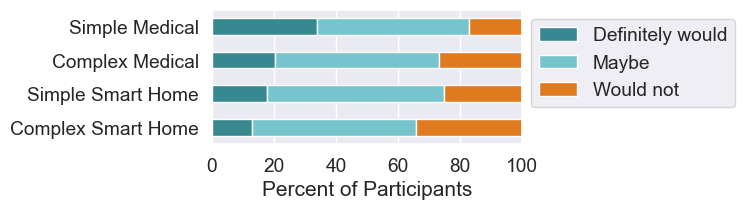

In [4692]:
med_c = medicalC_willingness_counts["willingness"]
med_s = medicalS_willingness_counts["willingness"]
iot_c = iotC_willingness_counts["willingness"]
iot_s = iotS_willingness_counts["willingness"]

all_willingness_chart = pd.DataFrame(med_c/sum(med_c) * 100).rename(
        columns={"willingness":"Complex Medical"}) \
    .join(pd.DataFrame(med_s/sum(med_s) * 100).rename(
        columns={"willingness":"Simple Medical"})) \
    .join(pd.DataFrame(iot_c/sum(iot_c) * 100).rename(
        columns={"willingness":"Complex Smart Home"})) \
    .join(pd.DataFrame(iot_s/sum(iot_s) * 100).rename(
        columns={"willingness":"Simple Smart Home"})) 

sns.set(font_scale=1.25)
sns.set_palette(['#388892','#75C4CE','#E07A1F','#DAB085'], n_colors=3)
ax = all_willingness_chart.transpose() \
    .sort_values(by=["Definitely would","Maybe"]) \
    .plot(kind='barh', stacked=True, figsize=(4,1.75))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), ncols=1) 

In [4693]:
hw_results = overall_willingness.loc[overall_willingness["S1"] == "Hardware"] \
        .drop(["S1","S2","S3"],axis=1)
trust_results = overall_willingness.loc[overall_willingness["S1"] == "Trust"] \
        .drop(["S1","S2","S3"],axis=1)
unsub_results = overall_willingness.loc[overall_willingness["S1"] == "Unsubstantial"] \
        .drop(["S1","S2","S3"],axis=1)
tech_results = overall_willingness.loc[overall_willingness["S2"] == "Technical"] \
        .drop(["S1","S2","S3"],axis=1)
untech_results = overall_willingness.loc[overall_willingness["S2"] == "Untechnical"] \
        .drop(["S1","S2","S3"],axis=1)
prevent_results = overall_willingness.loc[overall_willingness["S3"] == "Prevents"] \
        .drop(["S1","S2","S3"],axis=1)
noPrevent_results = overall_willingness.loc[overall_willingness["S3"] == "No Prevents"] \
        .drop(["S1","S2","S3"],axis=1)

willingnessMap = {
    "Definitely would" : "Definitely would",
    "Maybe would" : "Maybe",
    "Would not" : "Would not",
    "Not sure (Why?)" : "Maybe would"
}   

hw_results["willingness"] = hw_results["willingness"].map(willingnessMap)
trust_results["willingness"] = trust_results["willingness"].map(willingnessMap)
unsub_results["willingness"] = unsub_results["willingness"].map(willingnessMap)
tech_results["willingness"] = tech_results["willingness"].map(willingnessMap)
untech_results["willingness"] = untech_results["willingness"].map(willingnessMap)
prevent_results["willingness"] = prevent_results["willingness"].map(willingnessMap)
noPrevent_results["willingness"] = noPrevent_results["willingness"].map(willingnessMap)

willingness_scale_red = ["Definitely would","Maybe","Would not"]

hw_willingness_counts = hw_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
trust_willingness_counts = trust_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
unsub_willingness_counts = unsub_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
tech_willingness_counts = tech_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
untech_willingness_counts = untech_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
prevent_willingness_counts = prevent_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
noPrevent_willingness_counts = noPrevent_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)

all_willingness = pd.DataFrame(hw_willingness_counts).rename(columns={"willingness":"Hardware"}) \
    .join(pd.DataFrame(trust_willingness_counts.rename(columns={"willingness":"Trust"}))) \
    .join(pd.DataFrame(unsub_willingness_counts.rename(columns={"willingness":"Unsubstantial"}))) \
    .join(pd.DataFrame(tech_willingness_counts.rename(columns={"willingness":"Technical"}))) \
    .join(pd.DataFrame(untech_willingness_counts.rename(columns={"willingness":"Untechnical"}))) \
    .join(pd.DataFrame(prevent_willingness_counts.rename(columns={"willingness":"Prevents"}))) \
    .join(pd.DataFrame(noPrevent_willingness_counts.rename(columns={"willingness":"No Prevents"})))

all_willingness["Hardware"] = all_willingness["Hardware"] / len(hw_results)
all_willingness["Trust"] = all_willingness["Trust"] / len(trust_results)
all_willingness["Unsubstantial"] = all_willingness["Unsubstantial"] / len(unsub_results)
all_willingness["Technical"] = all_willingness["Technical"] / len(tech_results)
all_willingness["Untechnical"] = all_willingness["Untechnical"] / len(untech_results)
all_willingness["Prevents"] = all_willingness["Prevents"] / len(prevent_results)
all_willingness["No Prevents"] = all_willingness["No Prevents"] / len(noPrevent_results)
 
all_willingness.style.format('{:.1%}')

,Hardware,Trust,Unsubstantial,Technical,Untechnical,Prevents,No Prevents
Definitely would,22.0%,21.1%,20.5%,22.4%,20.0%,21.8%,20.6%
Maybe,55.7%,51.0%,52.2%,50.4%,55.5%,51.7%,54.3%
Would not,22.3%,27.9%,27.2%,27.1%,24.5%,26.5%,25.1%


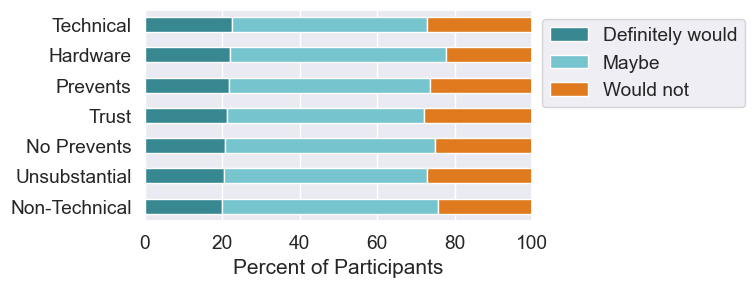

In [4694]:
hw = hw_willingness_counts["willingness"]
trust = trust_willingness_counts["willingness"]
unsub = unsub_willingness_counts["willingness"]
tech = tech_willingness_counts["willingness"]
untech = untech_willingness_counts["willingness"]
prevent = prevent_willingness_counts["willingness"]
noprevent = noPrevent_willingness_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(hw/sum(hw) * 100).rename(
        columns={"willingness":"Hardware"}) \
    .join(pd.DataFrame(trust/sum(trust) * 100).rename(
        columns={"willingness":"Trust"})) \
    .join(pd.DataFrame(unsub/sum(unsub) * 100).rename(
        columns={"willingness":"Unsubstantial"})) \
    .join(pd.DataFrame(tech/sum(tech) * 100).rename(
        columns={"willingness":"Technical"})) \
    .join(pd.DataFrame(untech/sum(untech) * 100).rename(
        columns={"willingness":"Non-Technical"})) \
    .join(pd.DataFrame(prevent/sum(prevent) * 100).rename(
        columns={"willingness":"Prevents"})) \
    .join(pd.DataFrame(noprevent/sum(noprevent) * 100).rename(
        columns={"willingness":"No Prevents"}))

sns.set(font_scale=1.25)
sns.set_palette(['#388892','#75C4CE','#E07A1F','#DAB085'], n_colors=4)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Definitely would", "Maybe"]) \
    .plot(kind='barh', stacked=True, figsize=(5,2.75))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), ncols=1) 

Medical scenarios

In [4695]:
hw_results = medical_willingness_results.loc[medical_willingness_results["S1"] == "Hardware"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
trust_results = medical_willingness_results.loc[medical_willingness_results["S1"] == "Trust"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
unsub_results = medical_willingness_results.loc[medical_willingness_results["S1"] == "Unsubstantial"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
tech_results = medical_willingness_results.loc[medical_willingness_results["S2"] == "Technical"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
untech_results = medical_willingness_results.loc[medical_willingness_results["S2"] == "Untechnical"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
prevent_results = medical_willingness_results.loc[medical_willingness_results["S3"] == "Prevents"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
noPrevent_results = medical_willingness_results.loc[medical_willingness_results["S3"] == "No Prevents"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)

willingnessMap = {
    "Definitely would" : "Definitely would",
    "Maybe would" : "Maybe would",
    "Would not" : "Would not",
    "Not sure (Why?)" : "Maybe would"
}   

hw_results["willingness"] = hw_results["willingness"].map(willingnessMap)
trust_results["willingness"] = trust_results["willingness"].map(willingnessMap)
unsub_results["willingness"] = unsub_results["willingness"].map(willingnessMap)
tech_results["willingness"] = tech_results["willingness"].map(willingnessMap)
untech_results["willingness"] = untech_results["willingness"].map(willingnessMap)
prevent_results["willingness"] = prevent_results["willingness"].map(willingnessMap)
noPrevent_results["willingness"] = noPrevent_results["willingness"].map(willingnessMap)

willingness_scale_red = ["Definitely would","Maybe would","Would not"]

hw_willingness_counts = hw_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
trust_willingness_counts = trust_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
unsub_willingness_counts = unsub_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
tech_willingness_counts = tech_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
untech_willingness_counts = untech_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
prevent_willingness_counts = prevent_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
noPrevent_willingness_counts = noPrevent_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)

all_willingness = pd.DataFrame(hw_willingness_counts).rename(columns={"willingness":"Hardware"}) \
    .join(pd.DataFrame(trust_willingness_counts.rename(columns={"willingness":"Trust"}))) \
    .join(pd.DataFrame(unsub_willingness_counts.rename(columns={"willingness":"Unsubstantial"}))) \
    .join(pd.DataFrame(tech_willingness_counts.rename(columns={"willingness":"Technical"}))) \
    .join(pd.DataFrame(untech_willingness_counts.rename(columns={"willingness":"Untechnical"}))) \
    .join(pd.DataFrame(prevent_willingness_counts.rename(columns={"willingness":"Prevents"}))) \
    .join(pd.DataFrame(noPrevent_willingness_counts.rename(columns={"willingness":"No Prevents"})))

all_willingness["Hardware"] = all_willingness["Hardware"] / len(hw_results)
all_willingness["Trust"] = all_willingness["Trust"] / len(trust_results)
all_willingness["Unsubstantial"] = all_willingness["Unsubstantial"] / len(unsub_results)
all_willingness["Technical"] = all_willingness["Technical"] / len(tech_results)
all_willingness["Untechnical"] = all_willingness["Untechnical"] / len(untech_results)
all_willingness["Prevents"] = all_willingness["Prevents"] / len(prevent_results)
all_willingness["No Prevents"] = all_willingness["No Prevents"] / len(noPrevent_results)
 
all_willingness.style.format('{:.1%}')

,Hardware,Trust,Unsubstantial,Technical,Untechnical,Prevents,No Prevents
Definitely would,27.7%,24.7%,28.8%,29.1%,25.1%,26.9%,27.2%
Maybe would,54.7%,51.3%,46.8%,47.9%,54.0%,51.7%,50.2%
Would not,17.6%,24.0%,24.4%,23.1%,20.9%,21.4%,22.6%


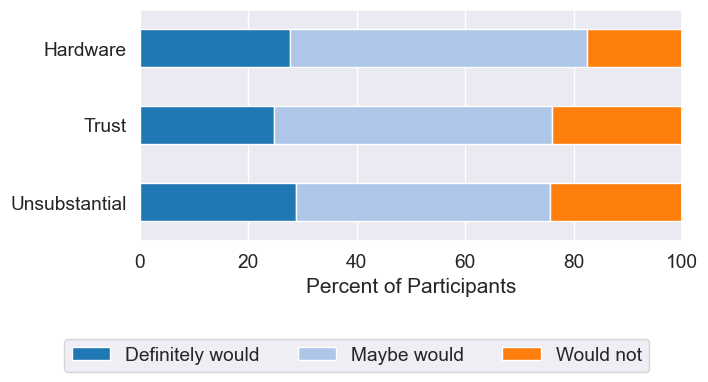

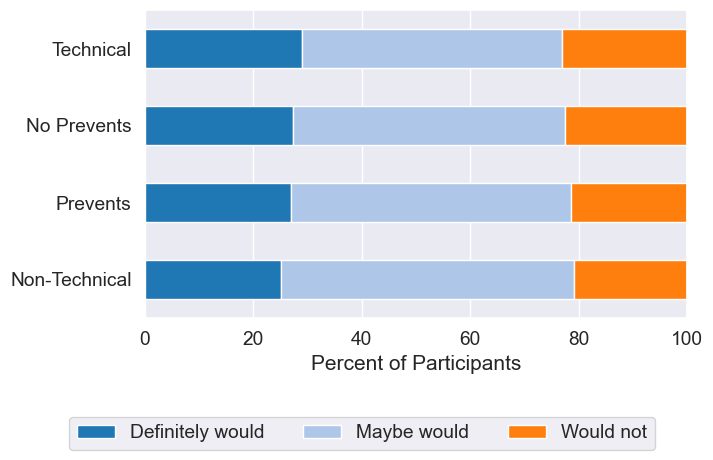

In [4696]:
hw = hw_willingness_counts["willingness"]
trust = trust_willingness_counts["willingness"]
unsub = unsub_willingness_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(hw/sum(hw) * 100).rename(
        columns={"willingness":"Hardware"}) \
    .join(pd.DataFrame(trust/sum(trust) * 100).rename(
        columns={"willingness":"Trust"})) \
    .join(pd.DataFrame(unsub/sum(unsub) * 100).rename(
        columns={"willingness":"Unsubstantial"})) 

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=4)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Maybe would"]) \
    .plot(kind='barh', stacked=True, figsize=(7,3))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.61), ncol=3) 


tech = tech_willingness_counts["willingness"]
untech = untech_willingness_counts["willingness"]
prevent = prevent_willingness_counts["willingness"]
noprevent = noPrevent_willingness_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(tech/sum(tech) * 100).rename(
        columns={"willingness":"Technical"}) \
    .join(pd.DataFrame(untech/sum(untech) * 100).rename(
        columns={"willingness":"Non-Technical"})) \
    .join(pd.DataFrame(prevent/sum(prevent) * 100).rename(
        columns={"willingness":"Prevents"})) \
    .join(pd.DataFrame(noprevent/sum(noprevent) * 100).rename(
        columns={"willingness":"No Prevents"}))

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=4)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Definitely would", "Maybe would"]) \
    .plot(kind='barh', stacked=True, figsize=(7,4))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.46), ncol=3)

Home IoT Scenarios

In [4697]:
hw_results = iot_willingness_results.loc[iot_willingness_results["S1"] == "Hardware"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
trust_results = iot_willingness_results.loc[iot_willingness_results["S1"] == "Trust"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
unsub_results = iot_willingness_results.loc[iot_willingness_results["S1"] == "Unsubstantial"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
tech_results = iot_willingness_results.loc[iot_willingness_results["S2"] == "Technical"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
untech_results = iot_willingness_results.loc[iot_willingness_results["S2"] == "Untechnical"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
prevent_results = iot_willingness_results.loc[iot_willingness_results["S3"] == "Prevents"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
noPrevent_results = iot_willingness_results.loc[iot_willingness_results["S3"] == "No Prevents"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)

willingnessMap = {
    "Definitely would" : "Definitely would",
    "Maybe would" : "Maybe would",
    "Would not" : "Would not",
    "Not sure (Why?)" : "Maybe would"
}   

hw_results["willingness"] = hw_results["willingness"].map(willingnessMap)
trust_results["willingness"] = trust_results["willingness"].map(willingnessMap)
unsub_results["willingness"] = unsub_results["willingness"].map(willingnessMap)
tech_results["willingness"] = tech_results["willingness"].map(willingnessMap)
untech_results["willingness"] = untech_results["willingness"].map(willingnessMap)
prevent_results["willingness"] = prevent_results["willingness"].map(willingnessMap)
noPrevent_results["willingness"] = noPrevent_results["willingness"].map(willingnessMap)

willingness_scale_red = ["Definitely would","Maybe would","Would not"]

hw_willingness_counts = hw_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
trust_willingness_counts = trust_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
unsub_willingness_counts = unsub_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
tech_willingness_counts = tech_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
untech_willingness_counts = untech_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
prevent_willingness_counts = prevent_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)
noPrevent_willingness_counts = noPrevent_results.apply(lambda col: col.value_counts()).reindex(willingness_scale_red).fillna(0)

all_willingness = pd.DataFrame(hw_willingness_counts).rename(columns={"willingness":"Hardware"}) \
    .join(pd.DataFrame(trust_willingness_counts.rename(columns={"willingness":"Trust"}))) \
    .join(pd.DataFrame(unsub_willingness_counts.rename(columns={"willingness":"Unsubstantial"}))) \
    .join(pd.DataFrame(tech_willingness_counts.rename(columns={"willingness":"Technical"}))) \
    .join(pd.DataFrame(untech_willingness_counts.rename(columns={"willingness":"Untechnical"}))) \
    .join(pd.DataFrame(prevent_willingness_counts.rename(columns={"willingness":"Prevents"}))) \
    .join(pd.DataFrame(noPrevent_willingness_counts.rename(columns={"willingness":"No Prevents"})))

all_willingness["Hardware"] = all_willingness["Hardware"] / len(hw_results)
all_willingness["Trust"] = all_willingness["Trust"] / len(trust_results)
all_willingness["Unsubstantial"] = all_willingness["Unsubstantial"] / len(unsub_results)
all_willingness["Technical"] = all_willingness["Technical"] / len(tech_results)
all_willingness["Untechnical"] = all_willingness["Untechnical"] / len(untech_results)
all_willingness["Prevents"] = all_willingness["Prevents"] / len(prevent_results)
all_willingness["No Prevents"] = all_willingness["No Prevents"] / len(noPrevent_results)
 
all_willingness.style.format('{:.1%}')

,Hardware,Trust,Unsubstantial,Technical,Untechnical,Prevents,No Prevents
Definitely would,16.4%,17.5%,12.2%,15.8%,14.9%,16.7%,14.0%
Maybe would,56.6%,50.6%,57.7%,53.0%,57.0%,51.7%,58.3%
Would not,27.0%,31.8%,30.1%,31.2%,28.1%,31.6%,27.7%


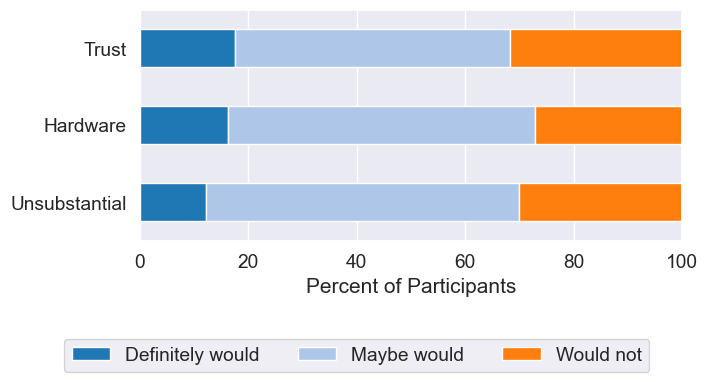

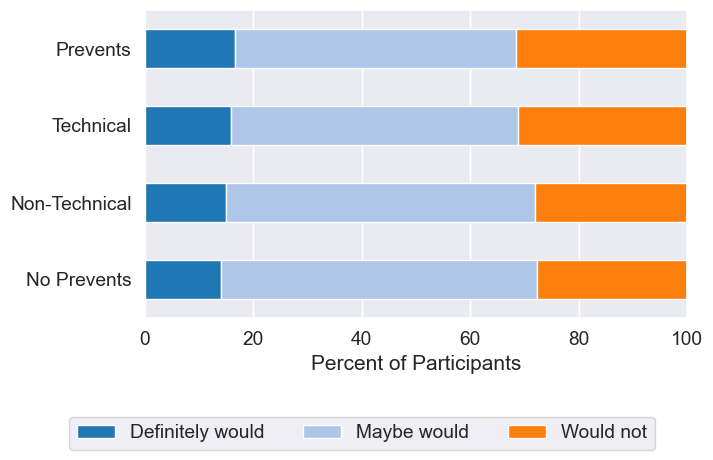

In [4698]:
hw = hw_willingness_counts["willingness"]
trust = trust_willingness_counts["willingness"]
unsub = unsub_willingness_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(hw/sum(hw) * 100).rename(
        columns={"willingness":"Hardware"}) \
    .join(pd.DataFrame(trust/sum(trust) * 100).rename(
        columns={"willingness":"Trust"})) \
    .join(pd.DataFrame(unsub/sum(unsub) * 100).rename(
        columns={"willingness":"Unsubstantial"})) 

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=4)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Definitely would", "Maybe would"]) \
    .plot(kind='barh', stacked=True, figsize=(7,3))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.61), ncol=3) 

tech = tech_willingness_counts["willingness"]
untech = untech_willingness_counts["willingness"]
prevent = prevent_willingness_counts["willingness"]
noprevent = noPrevent_willingness_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(tech/sum(tech) * 100).rename(
        columns={"willingness":"Technical"}) \
    .join(pd.DataFrame(untech/sum(untech) * 100).rename(
        columns={"willingness":"Non-Technical"})) \
    .join(pd.DataFrame(prevent/sum(prevent) * 100).rename(
        columns={"willingness":"Prevents"})) \
    .join(pd.DataFrame(noprevent/sum(noprevent) * 100).rename(
        columns={"willingness":"No Prevents"}))

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=4)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Definitely would", "Maybe would"]) \
    .plot(kind='barh', stacked=True, figsize=(7,4))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.46), ncol=3)

In [4699]:
medical_safety_results = results[["SCENARIO_Med","EXPLN_S1","EXPLN_S2","EXPLN_S3","safety-medical-init","safety-medical-post"]]
medical_safety_results.columns = ["Scenario","S1","S2","S3","safety (init)", "safety (post)"]

iot_safety_results = results[["SCENARIO_IoT","EXPLN_S1","EXPLN_S2","EXPLN_S3","safety-iot-init","safety-iot-post"]]
iot_safety_results.columns = ["Scenario","S1","S2","S3","safety (init)", "safety (post)"]

overall_safety = pd.concat([medical_safety_results.drop(["Scenario"],axis=1),
                        iot_safety_results.drop(["Scenario"],axis=1)],axis=0)

safety_scale = ["Completely safe","Somewhat safe","Not at all safe"]

In [4700]:
medicalC_results = medical_safety_results.loc[medical_safety_results["Scenario"] == "Medical-Complex"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)
medicalS_results = medical_safety_results.loc[medical_safety_results["Scenario"] == "Medical-Simple"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)
iotC_results = iot_safety_results.loc[iot_safety_results["Scenario"] == "IoT-Complex"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)
iotS_results = iot_safety_results.loc[iot_safety_results["Scenario"] == "IoT-Simple"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)

medicalC_safety_counts = medicalC_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
medicalS_safety_counts = medicalS_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
iotC_safety_counts = iotC_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
iotS_safety_counts = iotS_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

medicalC_safety_counts["safety (delta)"] = medicalC_safety_counts["safety (post)"] - medicalC_safety_counts["safety (init)"]
medicalS_safety_counts["safety (delta)"] = medicalS_safety_counts["safety (post)"] - medicalS_safety_counts["safety (init)"]
iotC_safety_counts["safety (delta)"] = iotC_safety_counts["safety (post)"] - iotC_safety_counts["safety (init)"]
iotS_safety_counts["safety (delta)"] = iotS_safety_counts["safety (post)"] - iotS_safety_counts["safety (init)"]

all_safety = pd.DataFrame(medicalC_safety_counts).rename(
        columns={"safety (init)":"Medical Complex (init)", "safety (post)":"Medical Complex (post)", "safety (delta)":"Medical Complex (delta)"}) \
    .join(pd.DataFrame(medicalS_safety_counts.rename(
        columns={"safety (init)":"Medical Simple (init)", "safety (post)":"Medical Simple (post)", "safety (delta)":"Medical Simple (delta)"}))) \
    .join(pd.DataFrame(iotC_safety_counts.rename(
        columns={"safety (init)":"IoT Complex (init)", "safety (post)":"IoT Complex (post)", "safety (delta)":"IoT Complex (delta)"}))) \
    .join(pd.DataFrame(iotS_safety_counts.rename(
        columns={"safety (init)":"IoT Simple (init)", "safety (post)":"IoT Simple (post)", "safety (delta)":"IoT Simple (delta)"}))) 

all_safety["Medical Complex (init)"] = all_safety["Medical Complex (init)"] / len(medicalC_results)
all_safety["Medical Simple (init)"] = all_safety["Medical Simple (init)"] / len(medicalS_results)
all_safety["IoT Complex (init)"] = all_safety["IoT Complex (init)"] / len(iotC_results)
all_safety["IoT Simple (init)"] = all_safety["IoT Simple (init)"] / len(iotS_results)
all_safety["Medical Complex (post)"] = all_safety["Medical Complex (post)"] / len(medicalC_results)
all_safety["Medical Simple (post)"] = all_safety["Medical Simple (post)"] / len(medicalS_results)
all_safety["IoT Complex (post)"] = all_safety["IoT Complex (post)"] / len(iotC_results)
all_safety["IoT Simple (post)"] = all_safety["IoT Simple (post)"] / len(iotS_results)
all_safety["Medical Complex (delta)"] = all_safety["Medical Complex (delta)"] / len(medicalC_results)
all_safety["Medical Simple (delta)"] = all_safety["Medical Simple (delta)"] / len(medicalS_results)
all_safety["IoT Complex (delta)"] = all_safety["IoT Complex (delta)"] / len(iotC_results)
all_safety["IoT Simple (delta)"] = all_safety["IoT Simple (delta)"] / len(iotS_results)

all_safety.style.format('{:.1%}')

,Medical Complex (init),Medical Complex (post),Medical Complex (delta),Medical Simple (init),Medical Simple (post),Medical Simple (delta),IoT Complex (init),IoT Complex (post),IoT Complex (delta),IoT Simple (init),IoT Simple (post),IoT Simple (delta)
Completely safe,21.6%,16.1%,-5.5%,34.3%,23.2%,-11.2%,21.9%,16.7%,-5.2%,27.1%,20.3%,-6.8%
Somewhat safe,69.9%,75.0%,5.1%,60.1%,72.5%,12.4%,65.7%,75.1%,9.4%,64.0%,74.6%,10.6%
Not at all safe,8.5%,8.9%,0.4%,5.6%,4.3%,-1.3%,12.4%,8.2%,-4.3%,8.9%,5.1%,-3.8%


In [4701]:
medicalC_results = medical_safety_results.loc[medical_safety_results["Scenario"] == "Medical-Complex"] \
    .drop(["Scenario","S1","S2","S3",'safety (post)'],axis=1)
medicalS_results = medical_safety_results.loc[medical_safety_results["Scenario"] == "Medical-Simple"] \
    .drop(["Scenario","S1","S2","S3",'safety (post)'],axis=1)
iotC_results = iot_safety_results.loc[iot_safety_results["Scenario"] == "IoT-Complex"] \
    .drop(["Scenario","S1","S2","S3",'safety (post)'],axis=1)
iotS_results = iot_safety_results.loc[iot_safety_results["Scenario"] == "IoT-Simple"] \
    .drop(["Scenario","S1","S2","S3",'safety (post)'],axis=1)

safetyMap = {
    "Completely safe" : "Completely",
    "Somewhat safe" : "Somewhat",
    "Not at all safe" : "Not at all"
}   

medicalC_results["safety (init)"] = medicalC_results["safety (init)"].map(safetyMap)
medicalS_results["safety (init)"] = medicalS_results["safety (init)"].map(safetyMap)
iotC_results["safety (init)"] = iotC_results["safety (init)"].map(safetyMap)
iotS_results["safety (init)"] = iotS_results["safety (init)"].map(safetyMap)

safety_scale = ["Completely","Somewhat","Not at all"]

medicalC_safety_counts = medicalC_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
medicalS_safety_counts = medicalS_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
iotC_safety_counts = iotC_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
iotS_safety_counts = iotS_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(medicalC_safety_counts).rename(
        columns={"safety (init)":"Medical Complex"}) \
    .join(pd.DataFrame(medicalS_safety_counts.rename(
        columns={"safety (init)":"Medical Simple"}))) \
    .join(pd.DataFrame(iotC_safety_counts.rename(
        columns={"safety (init)":"IoT Complex"}))) \
    .join(pd.DataFrame(iotS_safety_counts.rename(
        columns={"safety (init)":"IoT Simple"}))) 

all_safety["Medical Complex"] = all_safety["Medical Complex"] / len(medicalC_results)
all_safety["Medical Simple"] = all_safety["Medical Simple"] / len(medicalS_results)
all_safety["IoT Complex"] = all_safety["IoT Complex"] / len(iotC_results)
all_safety["IoT Simple"] = all_safety["IoT Simple"] / len(iotS_results)
all_safety.style.format('{:.1%}')

,Medical Complex,Medical Simple,IoT Complex,IoT Simple
Completely,21.6%,34.3%,21.9%,27.1%
Somewhat,69.9%,60.1%,65.7%,64.0%
Not at all,8.5%,5.6%,12.4%,8.9%


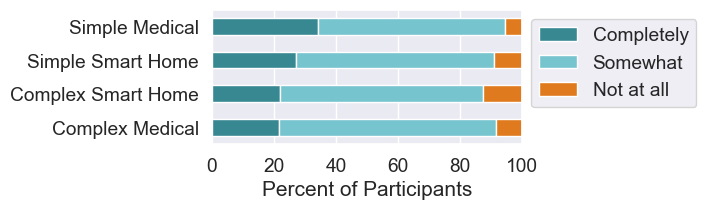

In [4702]:
med_c = medicalC_safety_counts["safety (init)"]
med_s = medicalS_safety_counts["safety (init)"]
iot_c = iotC_safety_counts["safety (init)"]
iot_s = iotS_safety_counts["safety (init)"]

all_safety_chart = pd.DataFrame(med_c/sum(med_c) * 100).rename(
        columns={"safety (init)":"Complex Medical"}) \
    .join(pd.DataFrame(med_s/sum(med_s) * 100).rename(
        columns={"safety (init)":"Simple Medical"})) \
    .join(pd.DataFrame(iot_c/sum(iot_c) * 100).rename(
        columns={"safety (init)":"Complex Smart Home"})) \
    .join(pd.DataFrame(iot_s/sum(iot_s) * 100).rename(
        columns={"safety (init)":"Simple Smart Home"})) 

sns.set(font_scale=1.25)
sns.set_palette(['#388892','#75C4CE','#E07A1F','#DAB085'], n_colors=3)
ax = all_safety_chart.transpose() \
    .sort_values(by=["Completely", "Somewhat"]) \
    .plot(kind='barh', stacked=True, figsize=(4,1.75))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), ncols=1)  

In [4703]:
hw_results = overall_safety.loc[overall_safety["S1"] == "Hardware"] \
        .drop(["S1","S2","S3"],axis=1)
trust_results = overall_safety.loc[overall_safety["S1"] == "Trust"] \
        .drop(["S1","S2","S3"],axis=1)
unsub_results = overall_safety.loc[overall_safety["S1"] == "Unsubstantial"] \
        .drop(["S1","S2","S3"],axis=1)
tech_results = overall_safety.loc[overall_safety["S2"] == "Technical"] \
        .drop(["S1","S2","S3"],axis=1)
untech_results = overall_safety.loc[overall_safety["S2"] == "Untechnical"] \
        .drop(["S1","S2","S3"],axis=1)
prevent_results = overall_safety.loc[overall_safety["S3"] == "Prevents"] \
        .drop(["S1","S2","S3"],axis=1)
noPrevent_results = overall_safety.loc[overall_safety["S3"] == "No Prevents"] \
        .drop(["S1","S2","S3"],axis=1)

safety_scale = ["Completely safe","Somewhat safe","Not at all safe"]

hw_safety_counts = hw_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_safety_counts = trust_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_safety_counts = unsub_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
tech_safety_counts = tech_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
untech_safety_counts = untech_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
prevent_safety_counts = prevent_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
noPrevent_safety_counts = noPrevent_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

hw_safety_counts["safety (delta)"] = hw_safety_counts["safety (post)"] - hw_safety_counts["safety (init)"]
trust_safety_counts["safety (delta)"] = trust_safety_counts["safety (post)"] - trust_safety_counts["safety (init)"]
unsub_safety_counts["safety (delta)"] = unsub_safety_counts["safety (post)"] - unsub_safety_counts["safety (init)"]
tech_safety_counts["safety (delta)"] = tech_safety_counts["safety (post)"] - tech_safety_counts["safety (init)"]
untech_safety_counts["safety (delta)"] = untech_safety_counts["safety (post)"] - untech_safety_counts["safety (init)"]
prevent_safety_counts["safety (delta)"] = prevent_safety_counts["safety (post)"] - prevent_safety_counts["safety (init)"]
noPrevent_safety_counts["safety (delta)"] = noPrevent_safety_counts["safety (post)"] - noPrevent_safety_counts["safety (init)"]

all_safety = pd.DataFrame(hw_safety_counts).rename(columns={
        "safety (init)":"Hardware (init)", "safety (post)":"Hardware (post)", "safety (delta)":"Hardware (delta)"}) \
    .join(pd.DataFrame(trust_safety_counts.rename(columns={
        "safety (init)":"Trust (init)", "safety (post)":"Trust (post)", "safety (delta)":"Trust (delta)"}))) \
    .join(pd.DataFrame(unsub_safety_counts.rename(columns={
        "safety (init)":"Unsubstantial (init)", "safety (post)":"Unsubstantial (post)", "safety (delta)":"Unsubstantial (delta)"}))) \
    .join(pd.DataFrame(tech_safety_counts.rename(columns={
        "safety (init)":"Technical (init)", "safety (post)":"Technical (post)", "safety (delta)":"Technical (delta)"}))) \
    .join(pd.DataFrame(untech_safety_counts.rename(columns={
        "safety (init)":"Untechnical (init)", "safety (post)":"Untechnical (post)", "safety (delta)":"Untechnical (delta)"}))) \
    .join(pd.DataFrame(prevent_safety_counts.rename(columns={
        "safety (init)":"Prevents (init)", "safety (post)":"Prevents (post)", "safety (delta)":"Prevents (delta)"}))) \
    .join(pd.DataFrame(noPrevent_safety_counts.rename(columns={
        "safety (init)":"No Prevents (init)", "safety (post)":"No Prevents (post)", "safety (delta)":"No Prevents (delta)"})))

all_safety["Hardware (init)"] = all_safety["Hardware (init)"] / len(hw_results)
all_safety["Trust (init)"] = all_safety["Trust (init)"] / len(trust_results)
all_safety["Unsubstantial (init)"] = all_safety["Unsubstantial (init)"] / len(unsub_results)
all_safety["Technical (init)"] = all_safety["Technical (init)"] / len(tech_results)
all_safety["Untechnical (init)"] = all_safety["Untechnical (init)"] / len(untech_results)
all_safety["Prevents (init)"] = all_safety["Prevents (init)"] / len(prevent_results)
all_safety["No Prevents (init)"] = all_safety["No Prevents (init)"] / len(noPrevent_results)
all_safety["Hardware (post)"] = all_safety["Hardware (post)"] / len(hw_results)
all_safety["Trust (post)"] = all_safety["Trust (post)"] / len(trust_results)
all_safety["Unsubstantial (post)"] = all_safety["Unsubstantial (post)"] / len(unsub_results)
all_safety["Technical (post)"] = all_safety["Technical (post)"] / len(tech_results)
all_safety["Untechnical (post)"] = all_safety["Untechnical (post)"] / len(untech_results)
all_safety["Prevents (post)"] = all_safety["Prevents (post)"] / len(prevent_results)
all_safety["No Prevents (post)"] = all_safety["No Prevents (post)"] / len(noPrevent_results)
all_safety["Hardware (delta)"] = all_safety["Hardware (delta)"] / len(hw_results)
all_safety["Trust (delta)"] = all_safety["Trust (delta)"] / len(trust_results)
all_safety["Unsubstantial (delta)"] = all_safety["Unsubstantial (delta)"] / len(unsub_results)
all_safety["Technical (delta)"] = all_safety["Technical (delta)"] / len(tech_results)
all_safety["Untechnical (delta)"] = all_safety["Untechnical (delta)"] / len(untech_results)
all_safety["Prevents (delta)"] = all_safety["Prevents (delta)"] / len(prevent_results)
all_safety["No Prevents (delta)"] = all_safety["No Prevents (delta)"] / len(noPrevent_results)
 
all_safety.style.format('{:.1%}')

,Hardware (init),Hardware (post),Hardware (delta),Trust (init),Trust (post),Trust (delta),Unsubstantial (init),Unsubstantial (post),Unsubstantial (delta),Technical (init),Technical (post),Technical (delta),Untechnical (init),Untechnical (post),Untechnical (delta),Prevents (init),Prevents (post),Prevents (delta),No Prevents (init),No Prevents (post),No Prevents (delta)
Completely safe,28.3%,20.8%,-7.5%,24.0%,16.9%,-7.1%,26.3%,19.6%,-6.7%,25.0%,17.9%,-7.1%,27.4%,20.2%,-7.2%,27.1%,20.5%,-6.6%,25.3%,17.7%,-7.7%
Somewhat safe,62.3%,71.4%,9.1%,66.9%,75.3%,8.4%,65.7%,76.3%,10.6%,65.4%,73.7%,8.3%,64.5%,74.9%,10.4%,64.1%,71.4%,7.3%,65.7%,77.2%,11.5%
Not at all safe,9.4%,7.9%,-1.6%,9.1%,7.8%,-1.3%,8.0%,4.2%,-3.8%,9.6%,8.3%,-1.3%,8.1%,4.9%,-3.2%,8.8%,8.1%,-0.6%,8.9%,5.1%,-3.8%


In [4704]:
hw_results = overall_safety.loc[overall_safety["S1"] == "Hardware"] \
        .drop(["S1","S2","S3", "safety (post)"],axis=1)
trust_results = overall_safety.loc[overall_safety["S1"] == "Trust"] \
        .drop(["S1","S2","S3", "safety (post)"],axis=1)
unsub_results = overall_safety.loc[overall_safety["S1"] == "Unsubstantial"] \
        .drop(["S1","S2","S3", "safety (post)"],axis=1)
tech_results = overall_safety.loc[overall_safety["S2"] == "Technical"] \
        .drop(["S1","S2","S3", "safety (post)"],axis=1)
untech_results = overall_safety.loc[overall_safety["S2"] == "Untechnical"] \
        .drop(["S1","S2","S3", "safety (post)"],axis=1)
prevent_results = overall_safety.loc[overall_safety["S3"] == "Prevents"] \
        .drop(["S1","S2","S3", "safety (post)"],axis=1)
noPrevent_results = overall_safety.loc[overall_safety["S3"] == "No Prevents"] \
        .drop(["S1","S2","S3", "safety (post)"],axis=1)

safetyMap = {
    "Completely safe" : "Completely",
    "Somewhat safe" : "Somewhat",
    "Not at all safe" : "Not at all"
}   

hw_results["safety (init)"] = hw_results["safety (init)"].map(safetyMap)
trust_results["safety (init)"] = trust_results["safety (init)"].map(safetyMap)
unsub_results["safety (init)"] = unsub_results["safety (init)"].map(safetyMap)
tech_results["safety (init)"] = tech_results["safety (init)"].map(safetyMap)
untech_results["safety (init)"] = untech_results["safety (init)"].map(safetyMap)
prevent_results["safety (init)"] = prevent_results["safety (init)"].map(safetyMap)
noPrevent_results["safety (init)"] = noPrevent_results["safety (init)"].map(safetyMap)

safety_scale = ["Completely","Somewhat","Not at all"]

hw_safety_counts = hw_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_safety_counts = trust_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_safety_counts = unsub_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
tech_safety_counts = tech_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
untech_safety_counts = untech_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
prevent_safety_counts = prevent_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
noPrevent_safety_counts = noPrevent_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(hw_safety_counts).rename(columns={
        "safety (init)":"Hardware (init)"}) \
    .join(pd.DataFrame(trust_safety_counts.rename(columns={
        "safety (init)":"Trust (init)"}))) \
    .join(pd.DataFrame(unsub_safety_counts.rename(columns={
        "safety (init)":"Unsubstantial (init)"}))) \
    .join(pd.DataFrame(tech_safety_counts.rename(columns={
        "safety (init)":"Technical (init)"}))) \
    .join(pd.DataFrame(untech_safety_counts.rename(columns={
        "safety (init)":"Untechnical (init)"}))) \
    .join(pd.DataFrame(prevent_safety_counts.rename(columns={
        "safety (init)":"Prevents (init)"}))) \
    .join(pd.DataFrame(noPrevent_safety_counts.rename(columns={
        "safety (init)":"No Prevents (init)"})))

all_safety["Hardware (init)"] = all_safety["Hardware (init)"] / len(hw_results)
all_safety["Trust (init)"] = all_safety["Trust (init)"] / len(trust_results)
all_safety["Unsubstantial (init)"] = all_safety["Unsubstantial (init)"] / len(unsub_results)
all_safety["Technical (init)"] = all_safety["Technical (init)"] / len(tech_results)
all_safety["Untechnical (init)"] = all_safety["Untechnical (init)"] / len(untech_results)
all_safety["Prevents (init)"] = all_safety["Prevents (init)"] / len(prevent_results)
all_safety["No Prevents (init)"] = all_safety["No Prevents (init)"] / len(noPrevent_results)

all_safety.style.format('{:.1%}')

,Hardware (init),Trust (init),Unsubstantial (init),Technical (init),Untechnical (init),Prevents (init),No Prevents (init)
Completely,28.3%,24.0%,26.3%,25.0%,27.4%,27.1%,25.3%
Somewhat,62.3%,66.9%,65.7%,65.4%,64.5%,64.1%,65.7%
Not at all,9.4%,9.1%,8.0%,9.6%,8.1%,8.8%,8.9%


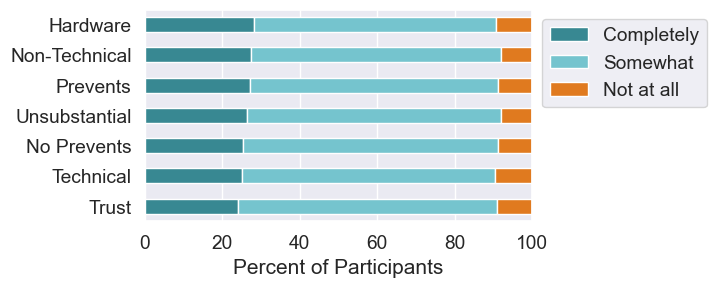

In [4705]:
hw = hw_safety_counts["safety (init)"]
trust = trust_safety_counts["safety (init)"]
unsub = unsub_safety_counts["safety (init)"]
tech = tech_safety_counts["safety (init)"]
untech = untech_safety_counts["safety (init)"]
prevent = prevent_safety_counts["safety (init)"]
noprevent = noPrevent_safety_counts["safety (init)"]

treatment_safety_chart = pd.DataFrame(hw/sum(hw) * 100).rename(
        columns={"safety (init)":"Hardware"}) \
    .join(pd.DataFrame(trust/sum(trust) * 100).rename(
        columns={"safety (init)":"Trust"})) \
    .join(pd.DataFrame(unsub/sum(unsub) * 100).rename(
        columns={"safety (init)":"Unsubstantial"})) \
    .join(pd.DataFrame(tech/sum(tech) * 100).rename(
        columns={"safety (init)":"Technical"})) \
    .join(pd.DataFrame(untech/sum(untech) * 100).rename(
        columns={"safety (init)":"Non-Technical"})) \
    .join(pd.DataFrame(prevent/sum(prevent) * 100).rename(
        columns={"safety (init)":"Prevents"})) \
    .join(pd.DataFrame(noprevent/sum(noprevent) * 100).rename(
        columns={"safety (init)":"No Prevents"}))

sns.set(font_scale=1.25)
sns.set_palette(['#388892','#75C4CE','#E07A1F','#DAB085'], n_colors=4)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Completely", "Somewhat"]) \
    .plot(kind='barh', stacked=True, figsize=(5,2.75))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), ncols=1) 

Medical scenarios only

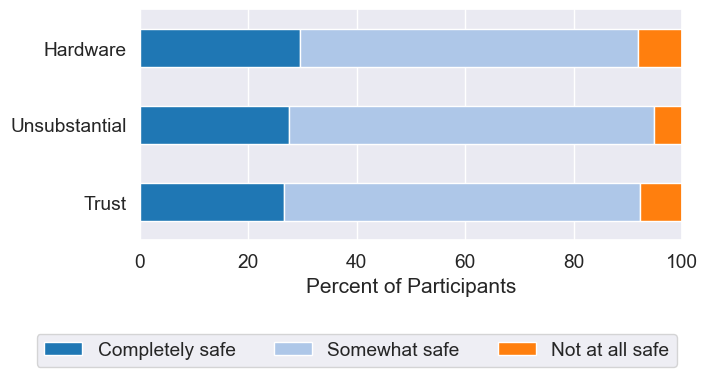

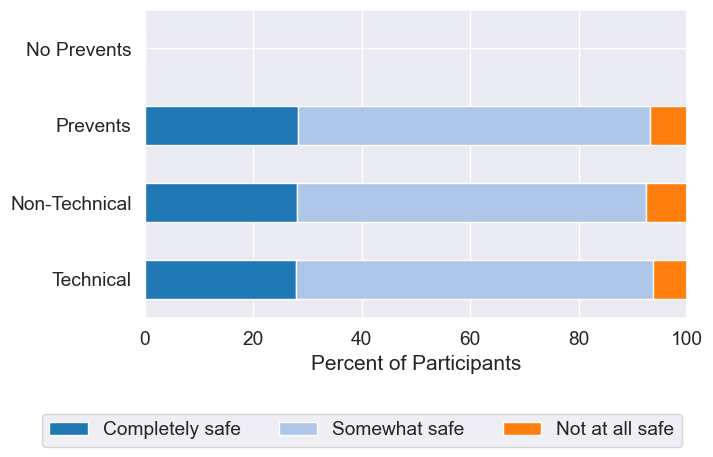

In [4706]:
hw_results = medical_safety_results.loc[medical_safety_results["S1"] == "Hardware"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
trust_results = medical_safety_results.loc[medical_safety_results["S1"] == "Trust"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
unsub_results = medical_safety_results.loc[medical_safety_results["S1"] == "Unsubstantial"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
tech_results = medical_safety_results.loc[medical_safety_results["S2"] == "Technical"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
untech_results = medical_safety_results.loc[medical_safety_results["S2"] == "Untechnical"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
prevent_results = medical_safety_results.loc[medical_safety_results["S3"] == "Prevents"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
noPrevent_results = medical_safety_results.loc[medical_safety_results["S3"] == "No Prevents"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)

safety_scale = ["Completely safe","Somewhat safe","Not at all safe"]

hw = hw_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]
trust = trust_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]
unsub = unsub_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]

treatment_safety_chart = pd.DataFrame(hw/sum(hw) * 100).rename(
        columns={"safety (init)":"Hardware"}) \
    .join(pd.DataFrame(trust/sum(trust) * 100).rename(
        columns={"safety (init)":"Trust"})) \
    .join(pd.DataFrame(unsub/sum(unsub) * 100).rename(
        columns={"safety (init)":"Unsubstantial"})) 

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=4)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Completely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.59), ncol = 3) 

tech = tech_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]
untech = untech_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]
prevent = prevent_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]
noPrevent = noPrevent_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]

treatment_safety_chart = pd.DataFrame(tech/sum(tech) * 100).rename(
        columns={"safety (init)":"Technical"}) \
    .join(pd.DataFrame(untech/sum(untech) * 100).rename(
        columns={"safety (init)":"Non-Technical"})) \
    .join(pd.DataFrame(prevent/sum(prevent) * 100).rename(
        columns={"safety (init)":"Prevents"})) \
    .join(pd.DataFrame(noprevent/sum(noprevent) * 100).rename(
        columns={"safety (init)":"No Prevents"}))

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=4)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Completely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7,4))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.45), ncol=3)

IoT scenarios only

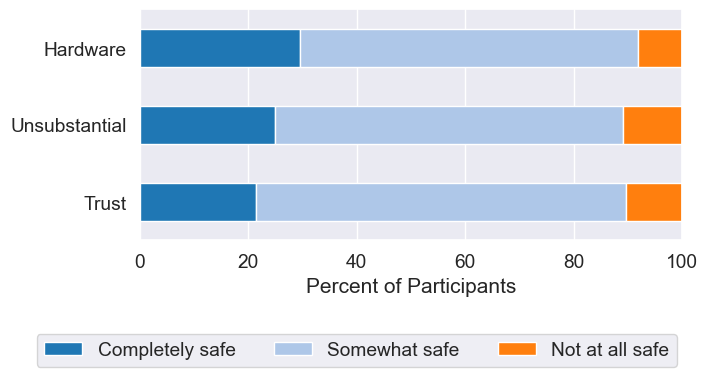

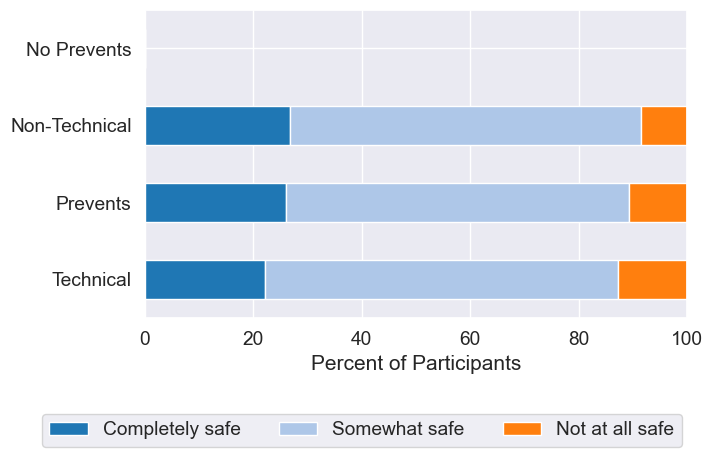

In [4707]:
hw_results = iot_safety_results.loc[iot_safety_results["S1"] == "Hardware"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
trust_results = iot_safety_results.loc[iot_safety_results["S1"] == "Trust"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
unsub_results = iot_safety_results.loc[iot_safety_results["S1"] == "Unsubstantial"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
tech_results = iot_safety_results.loc[iot_safety_results["S2"] == "Technical"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
untech_results = iot_safety_results.loc[iot_safety_results["S2"] == "Untechnical"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
prevent_results = iot_safety_results.loc[iot_safety_results["S3"] == "Prevents"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)
noPrevent_results = iot_safety_results.loc[iot_safety_results["S3"] == "No Prevents"] \
        .drop(["Scenario", "S1","S2","S3"],axis=1)

hws = hw_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]
trust = trust_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]
unsub = unsub_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]

treatment_safety_chart = pd.DataFrame(hw/sum(hw) * 100).rename(
        columns={"safety (init)":"Hardware"}) \
    .join(pd.DataFrame(trust/sum(trust) * 100).rename(
        columns={"safety (init)":"Trust"})) \
    .join(pd.DataFrame(unsub/sum(unsub) * 100).rename(
        columns={"safety (init)":"Unsubstantial"})) 

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=4)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Completely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.59), ncol = 3) 

tech = tech_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]
untech = untech_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]
prevent = prevent_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]
noPrevent = noPrevent_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)["safety (init)"]

treatment_safety_chart = pd.DataFrame(tech/sum(tech) * 100).rename(
        columns={"safety (init)":"Technical"}) \
    .join(pd.DataFrame(untech/sum(untech) * 100).rename(
        columns={"safety (init)":"Non-Technical"})) \
    .join(pd.DataFrame(prevent/sum(prevent) * 100).rename(
        columns={"safety (init)":"Prevents"})) \
    .join(pd.DataFrame(noprevent/sum(noprevent) * 100).rename(
        columns={"safety (init)":"No Prevents"}))

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=4)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Completely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7,4))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.45), ncol=3)

In [4708]:
medical_change_results = results[["SCENARIO_Med","EXPLN_S1","EXPLN_S2","EXPLN_S3","willingness-medical-delta"]].fillna("I have no questions")
medical_change_results.columns = ["Scenario","S1","S2","S3","change"]

iot_change_results = results[["SCENARIO_IoT","EXPLN_S1","EXPLN_S2","EXPLN_S3","willingness-iot-delta"]].fillna("I have no questions")
iot_change_results.columns = ["Scenario","S1","S2","S3","change"]

overall_change = pd.concat([medical_change_results.drop(["Scenario"],axis=1),
                        iot_change_results.drop(["Scenario"],axis=1)],axis=0)

change_scale = ["Definitely would change","Probably would change","Probably would not change","Definitely would not change","I have no questions"]

In [4709]:
medicalC_results = medical_change_results.loc[medical_change_results["Scenario"] == "Medical-Complex"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)
medicalS_results = medical_change_results.loc[medical_change_results["Scenario"] == "Medical-Simple"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)
iotC_results = iot_change_results.loc[iot_change_results["Scenario"] == "IoT-Complex"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)
iotS_results = iot_change_results.loc[iot_change_results["Scenario"] == "IoT-Simple"] \
    .drop(["Scenario","S1","S2","S3",],axis=1)

medicalC_change_counts = medicalC_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)
medicalS_change_counts = medicalS_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)
iotC_change_counts = iotC_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)
iotS_change_counts = iotS_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)

all_change = pd.DataFrame(medicalC_change_counts).rename(columns={"change":"Medical Complex"}) \
    .join(pd.DataFrame(medicalS_change_counts.rename(columns={"change":"Medical Simple"}))) \
    .join(pd.DataFrame(iotC_change_counts.rename(columns={"change":"IoT Complex"}))) \
    .join(pd.DataFrame(iotS_change_counts.rename(columns={"change":"IoT Simple"})))

print(all_change)

                             Medical Complex  Medical Simple  IoT Complex  IoT Simple
Definitely would change                   13              19            7          13
Probably would change                     72              56           69          65
Probably would not change                 70              62           68          67
Definitely would not change               15              18           28          15
I have no questions                       66              78           61          76


In [4710]:
hw_results = overall_change.loc[overall_change["S1"] == "Hardware"] \
        .drop(["S1","S2","S3"],axis=1)
trust_results = overall_change.loc[overall_change["S1"] == "Trust"] \
        .drop(["S1","S2","S3"],axis=1)
unsub_results = overall_change.loc[overall_change["S1"] == "Unsubstantial"] \
        .drop(["S1","S2","S3"],axis=1)
tech_results = overall_change.loc[overall_change["S2"] == "Technical"] \
        .drop(["S1","S2","S3"],axis=1)
untech_results = overall_change.loc[overall_change["S2"] == "Untechnical"] \
        .drop(["S1","S2","S3"],axis=1)
prevent_results = overall_change.loc[overall_change["S3"] == "Prevents"] \
        .drop(["S1","S2","S3"],axis=1)
noPrevent_results = overall_change.loc[overall_change["S3"] == "No Prevents"] \
        .drop(["S1","S2","S3"],axis=1)

hw_change_counts = hw_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)
trust_change_counts = trust_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)
unsub_change_counts = unsub_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)
tech_change_counts = tech_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)
untech_change_counts = untech_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)
prevent_change_counts = prevent_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)
noPrevent_change_counts = noPrevent_results.apply(lambda col: col.value_counts()).reindex(change_scale).fillna(0)

all_change = pd.DataFrame(hw_change_counts).rename(columns={"change":"Hardware"}) \
    .join(pd.DataFrame(trust_change_counts.rename(columns={"change":"Trust"}))) \
    .join(pd.DataFrame(unsub_change_counts.rename(columns={"change":"Unsubstantial"}))) \
    .join(pd.DataFrame(tech_change_counts.rename(columns={"change":"Technical"}))) \
    .join(pd.DataFrame(untech_change_counts.rename(columns={"change":"Untechnical"}))) \
    .join(pd.DataFrame(prevent_change_counts.rename(columns={"change":"Prevents"}))) \
    .join(pd.DataFrame(noPrevent_change_counts.rename(columns={"change":"No Prevents"})))

print(all_change)

                             Hardware  Trust  Unsubstantial  Technical  Untechnical  Prevents  No Prevents
Definitely would change            15     24             13         29           23        31           21
Probably would change              90     79             93        132          130       116          146
Probably would not change          85     89             93        130          137       135          132
Definitely would not change        24     26             26         42           34        34           42
I have no questions               104     90             87        135          146       152          129


# Confidence Analysis
* Scenario confidence?
* TEE confidence?
* More/less confident after concept question round 1? Round 2?
* More/less safe after concept questions round 1? Round 2?

In [4711]:
medical_confidence_results = results[["SCENARIO_Med","conf-scenario-medical"]]
medical_confidence_results.columns = ["Scenario","confidence"]

iot_confidence_results = results[["SCENARIO_IoT","conf-scenario-iot"]]
iot_confidence_results.columns = ["Scenario","confidence"]

overall_confidence = pd.concat([medical_confidence_results.drop(["Scenario"],axis=1),
                        iot_confidence_results.drop(["Scenario"],axis=1)],axis=0)

confidence_scale = ["Completely confident","Somewhat confident","Not at all confident"]

medicalC_results = medical_confidence_results.loc[medical_confidence_results["Scenario"] == "Medical-Complex"] \
    .drop(["Scenario"],axis=1)
medicalS_results = medical_confidence_results.loc[medical_confidence_results["Scenario"] == "Medical-Simple"] \
    .drop(["Scenario"],axis=1)
iotC_results = iot_confidence_results.loc[iot_confidence_results["Scenario"] == "IoT-Complex"] \
    .drop(["Scenario"],axis=1)
iotS_results = iot_confidence_results.loc[iot_confidence_results["Scenario"] == "IoT-Simple"] \
    .drop(["Scenario"],axis=1)

medicalC_confidence_counts = medicalC_results.apply(lambda col: col.value_counts()).reindex(confidence_scale).fillna(0)
medicalS_confidence_counts = medicalS_results.apply(lambda col: col.value_counts()).reindex(confidence_scale).fillna(0)
iotC_confidence_counts = iotC_results.apply(lambda col: col.value_counts()).reindex(confidence_scale).fillna(0)
iotS_confidence_counts = iotS_results.apply(lambda col: col.value_counts()).reindex(confidence_scale).fillna(0)
overall_confidence_counts = overall_confidence.apply(lambda col: col.value_counts()).reindex(confidence_scale).fillna(0)

all_confidence = pd.DataFrame(medicalC_confidence_counts).rename(columns={"confidence":"Medical Complex"}) \
    .join(pd.DataFrame(medicalS_confidence_counts.rename(columns={"confidence":"Medical Simple"}))) \
    .join(pd.DataFrame(iotC_confidence_counts.rename(columns={"confidence":"IoT Complex"}))) \
    .join(pd.DataFrame(iotS_confidence_counts.rename(columns={"confidence":"IoT Simple"}))) \
    .join(pd.DataFrame(overall_confidence_counts).rename(columns={"confidence":"Overall"}))

print(all_confidence)

                      Medical Complex  Medical Simple  IoT Complex  IoT Simple  Overall
Completely confident              131             142          128         127      528
Somewhat confident                101              87           95         105      388
Not at all confident                4               4           10           4       22


# Question Analysis
* How many people have questions after the medical scenario? IoT scenario?
* How many people have questions after the first scenario? Second scenario?
* How do the questions compare between scenario?
* How do the questions compare between TEE explanations?

In [4712]:
qual_results = pd.read_csv('./export/qualitative_data_coded.csv', encoding=ENCODING)

medical_qual_results = qual_results[["med_distrust", "med_risk", "med_risk2",
            "med_gen", "med_gen2", "med_use", "med_scenario", "med_scenario2", "med_guarantees",
            "SCENARIO_Med", "EXPLN_S1", "EXPLN_S2", "EXPLN_S3"]]
iot_qual_results = qual_results[["iot_distrust", "iot_risk", "iot_risk2",
            "iot_gen", "iot_gen2", "iot_use", "iot_scenario", "iot_scenario2", "iot_guarantees",
            "SCENARIO_IoT", "EXPLN_S1", "EXPLN_S2", "EXPLN_S3"]]

medicalC_results_all = medical_qual_results.loc[medical_qual_results["SCENARIO_Med"] == "Medical-Complex"] \
    .drop(["SCENARIO_Med","EXPLN_S1","EXPLN_S2","EXPLN_S3"],axis=1)
medicalS_results_all = medical_qual_results.loc[medical_qual_results["SCENARIO_Med"] == "Medical-Simple"] \
    .drop(["SCENARIO_Med","EXPLN_S1","EXPLN_S2","EXPLN_S3"],axis=1)
iotC_results_all = iot_qual_results.loc[iot_qual_results["SCENARIO_IoT"] == "IoT-Complex"] \
    .drop(["SCENARIO_IoT","EXPLN_S1","EXPLN_S2","EXPLN_S3"],axis=1)
iotS_results_all = iot_qual_results.loc[iot_qual_results["SCENARIO_IoT"] == "IoT-Simple"] \
    .drop(["SCENARIO_IoT","EXPLN_S1","EXPLN_S2","EXPLN_S3"],axis=1)

In [4713]:
count_med_coded = medical_qual_results.drop(["EXPLN_S1", "EXPLN_S2", "EXPLN_S3", "SCENARIO_Med"], axis=1)
count_iot_coded = iot_qual_results.drop(["EXPLN_S1", "EXPLN_S2", "EXPLN_S3", "SCENARIO_IoT"], axis=1)

med_code_count = count_med_coded.count(axis=1).astype(bool).sum(axis=0)
iot_code_count = count_iot_coded.count(axis=1).astype(bool).sum(axis=0)

all_count = qual_results.drop(["ResponseId", "id", 
    "What questions do you still have about TEEs, if any? (medical)", "SCENARIO_Med", 
    "questions-IoT-merged", "SCENARIO_IoT", "EXPLN_S1", "EXPLN_S2", "EXPLN_S3", 
    "notes", "Other feedback", "code_feedback"], axis=1)

print("Total number of questions coded  (medical): " + str(med_code_count))
print("Total number of questions coded (IoT): " + str(iot_code_count))
print("Total number of questions coded: " + str(med_code_count + iot_code_count) 
      + " from " + str(all_count.count(axis=1).astype(bool).sum(axis=0)) + " people")

Total number of questions coded  (medical): 161
Total number of questions coded (IoT): 149
Total number of questions coded: 310 from 252 people


In [4714]:
medicalC_code_counts = medicalC_results_all.apply(lambda col: col.value_counts()).fillna(0)
medicalS_code_counts = medicalS_results_all.apply(lambda col: col.value_counts()).fillna(0)
iotC_code_counts = iotC_results_all.apply(lambda col: col.value_counts()).fillna(0)
iotS_code_counts = iotS_results_all.apply(lambda col: col.value_counts()).fillna(0)

# set up new dataframe with all qual codes
## need to re-index dataframes since we used med_ for medical codes and iot_ for iot codes
all_categories = pd.DataFrame(medicalC_code_counts.sum(axis=0),columns=["Medical Complex"]) \
        .rename(index=dict(zip(medicalC_code_counts.columns, surveyfields.qualCategories))) \
    .join(pd.DataFrame(medicalS_code_counts.sum(axis=0),columns=["Medical Simple"]) \
        .rename(index=dict(zip(medicalS_code_counts.columns, surveyfields.qualCategories)))) \
    .join(pd.DataFrame(iotC_code_counts.sum(axis=0),columns=["IoT Complex"]) \
        .rename(index=dict(zip(iotC_code_counts.columns, surveyfields.qualCategories)))) \
    .join(pd.DataFrame(iotS_code_counts.sum(axis=0),columns=["IoT Simple"]) \
        .rename(index=dict(zip(iotS_code_counts.columns, surveyfields.qualCategories))))

print('Number of responses receiving at least one gen code: ' + str(sum(all_categories.loc['gen'])))
print('Number of responses receiving at least one risk code: ' + str(sum(all_categories.loc['risk'])))
print('Number of responses receiving at least one scenario code: ' + str(sum(all_categories.loc['scenario'])))

# combine rows where multiple codes from the same category were applied
all_categories.loc['risk'] += all_categories.loc['risk2']
all_categories.loc['gen'] += all_categories.loc['gen2']
all_categories.loc['scenario'] += all_categories.loc['scenario2']
all_categories.drop(['risk2', 'gen2', 'scenario2'], inplace=True)

print(all_categories)

Number of responses receiving at least one gen code: 143.0
Number of responses receiving at least one risk code: 74.0
Number of responses receiving at least one scenario code: 91.0
            Medical Complex  Medical Simple  IoT Complex  IoT Simple
distrust               13.0             6.0         15.0         9.0
risk                   28.0            27.0         15.0        16.0
gen                    47.0            54.0         34.0        38.0
use                     4.0             6.0          8.0         3.0
scenario               28.0            18.0         30.0        27.0
guarantees             15.0            15.0         12.0         9.0


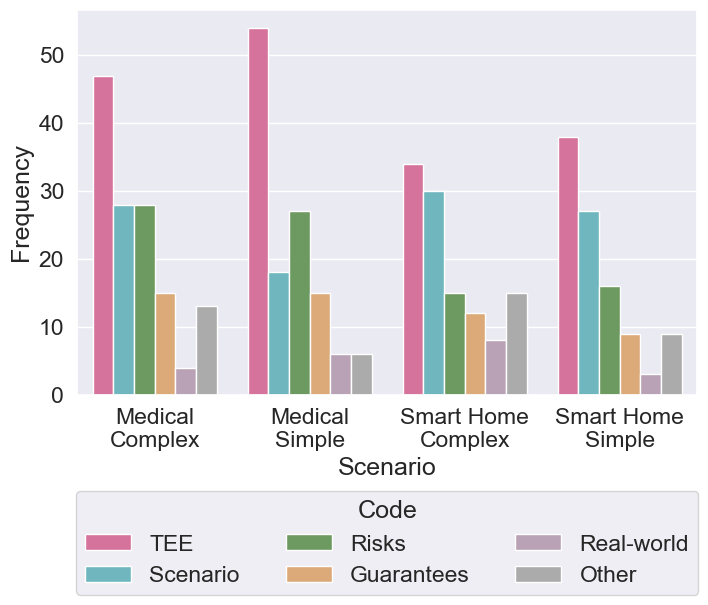

In [4715]:
scenarios = ["Medical Complex", "Medical Simple", "IoT Complex", "IoT Simple"]
codes = ['gen', 'scenario', 'risk', 'guarantees', 'use', 'distrust']

df = pd.DataFrame()
for scenario in scenarios:
    for code in codes:
        df = pd.concat([df,
            pd.DataFrame({"Scenario": scenario, 
                          "Code":code, 
                          "Frequency":all_categories.loc[code,scenario]},
                         index = [0])],
            ignore_index=True)

df.replace("Medical Complex","Medical\nComplex", inplace=True)
df.replace("Medical Simple","Medical\nSimple", inplace=True)
df.replace("IoT Complex","Smart Home\nComplex", inplace=True)
df.replace("IoT Simple","Smart Home\nSimple", inplace=True)
df.replace("gen","TEE", inplace=True)
df.replace("risk","Risks", inplace=True)
df.replace("use","Real-world", inplace=True)
df.replace("distrust","Other", inplace=True)
df.replace("scenario","Scenario", inplace=True)
df.replace("guarantees","Guarantees", inplace=True)

sns.set(font_scale=1.5)
sns.set_palette(['#E56399','#63C0CC','#68A357','#ECAA69','#BD9EB9','#ABABAB'], n_colors=6)
fig, ax = plt.subplots(figsize=(8, 5))
ax = sns.barplot(data=df, x="Scenario", y="Frequency", hue="Code", ax=ax)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.5, -0.55), ncol=3)

In [4716]:
# just medical vs IoT
med_iot_categories = all_categories.copy()
med_iot_categories["Medical Complex"] += med_iot_categories["Medical Simple"]
med_iot_categories["IoT Complex"] += med_iot_categories["IoT Simple"]
med_iot_categories.drop(["Medical Simple", "IoT Simple"], axis=1, inplace=True)
med_iot_categories.rename({"Medical Complex":"Medical", "IoT Complex":"IoT"}, axis=1, inplace=True)
med_iot_categories["Overall"] = med_iot_categories["Medical"] + med_iot_categories["IoT"]

print(med_iot_categories)

            Medical   IoT  Overall
distrust       19.0  24.0     43.0
risk           55.0  31.0     86.0
gen           101.0  72.0    173.0
use            10.0  11.0     21.0
scenario       46.0  57.0    103.0
guarantees     30.0  21.0     51.0


In [4717]:
medicalC_code_counts = medicalC_results_all.apply(lambda col: col.value_counts()).reindex(surveyfields.qualCodes).fillna(0)
medicalS_code_counts = medicalS_results_all.apply(lambda col: col.value_counts()).reindex(surveyfields.qualCodes).fillna(0)
iotC_code_counts = iotC_results_all.apply(lambda col: col.value_counts()).reindex(surveyfields.qualCodes).fillna(0)
iotS_code_counts = iotS_results_all.apply(lambda col: col.value_counts()).reindex(surveyfields.qualCodes).fillna(0)

all_codes = pd.DataFrame(medicalC_code_counts.sum(axis=1),columns=["Medical Complex"]) \
    .join(pd.DataFrame(medicalS_code_counts.sum(axis=1),columns=["Medical Simple"])) \
    .join(pd.DataFrame(iotC_code_counts.sum(axis=1),columns=["IoT Complex"])) \
    .join(pd.DataFrame(iotS_code_counts.sum(axis=1),columns=["IoT Simple"]))


print(all_codes)

                        Medical Complex  Medical Simple  IoT Complex  IoT Simple
Distrust:Vague                      7.0             4.0          3.0         2.0
Distrust:TEE                        5.0             2.0          1.0         2.0
Distrust:Scenario                   1.0             0.0          8.0         1.0
Distrust:Manufactuerer              0.0             0.0          3.0         4.0
Risk:Hacking                        9.0             6.0          3.0         9.0
Risk:People                         8.0             5.0          7.0         3.0
Risk:General                        4.0             9.0          4.0         3.0
Risk:Real                           2.0             0.0          0.0         1.0
Risk:Fail                           5.0             6.0          1.0         0.0
Risk:Tamper                         0.0             1.0          0.0         0.0
Gen:Isolation                       3.0            10.0          5.0         3.0
Gen:How?                    

In [4718]:
# just medical vs IoT
med_iot_all = all_codes.copy()
med_iot_all["Medical Complex"] += med_iot_all["Medical Simple"]
med_iot_all["IoT Complex"] += med_iot_all["IoT Simple"]
med_iot_all.drop(["Medical Simple", "IoT Simple"], axis=1, inplace=True)
med_iot_all.rename({"Medical Complex":"Medical", "IoT Complex":"IoT"}, axis=1, inplace=True)
med_iot_all["Overall"] = med_iot_all["Medical"] + med_iot_all["IoT"]

print(med_iot_all)

                        Medical   IoT  Overall
Distrust:Vague             11.0   5.0     16.0
Distrust:TEE                7.0   3.0     10.0
Distrust:Scenario           1.0   9.0     10.0
Distrust:Manufactuerer      0.0   7.0      7.0
Risk:Hacking               15.0  12.0     27.0
Risk:People                13.0  10.0     23.0
Risk:General               13.0   7.0     20.0
Risk:Real                   2.0   1.0      3.0
Risk:Fail                  11.0   1.0     12.0
Risk:Tamper                 1.0   0.0      1.0
Gen:Isolation              13.0   8.0     21.0
Gen:How?                   32.0  17.0     49.0
Gen:Auth                    3.0   2.0      5.0
Gen:Implementation         11.0   4.0     15.0
Gen:Features                9.0   6.0     15.0
Gen:Answered                3.0  10.0     13.0
Gen:Encryption              5.0   6.0     11.0
Gen:Tech                    4.0   5.0      9.0
Gen:Transmit                2.0   2.0      4.0
Gen:Misc                   14.0  12.0     26.0
Gen:Password 

In [4719]:
overall_qual = pd.concat([medical_qual_results.drop(["SCENARIO_Med"],axis=1),
                        iot_qual_results.drop(["SCENARIO_IoT"],axis=1)],axis=0)
expln_fields = ["EXPLN_S1", "EXPLN_S2", "EXPLN_S3"]

hw_results = overall_qual.loc[overall_qual["EXPLN_S1"] == "Hardware"].drop(expln_fields,axis=1)
trust_results = overall_qual.loc[overall_qual["EXPLN_S1"] == "Trust"].drop(expln_fields,axis=1)
unsub_results = overall_qual.loc[overall_qual["EXPLN_S1"] == "Unsubstantial"].drop(expln_fields,axis=1)
tech_results = overall_qual.loc[overall_qual["EXPLN_S2"] == "Technical"].drop(expln_fields,axis=1)
untech_results = overall_qual.loc[overall_qual["EXPLN_S2"] == "Untechnical"].drop(expln_fields,axis=1)
prevent_results = overall_qual.loc[overall_qual["EXPLN_S3"] == "Prevents"].drop(expln_fields,axis=1)
noPrevent_results = overall_qual.loc[overall_qual["EXPLN_S3"] == "No Prevents"].drop(expln_fields,axis=1)

hw_code_counts = hw_results.apply(lambda col: col.value_counts()).fillna(0)
trust_code_counts = trust_results.apply(lambda col: col.value_counts()).fillna(0)
unsub_code_counts = unsub_results.apply(lambda col: col.value_counts()).fillna(0)
tech_code_counts = tech_results.apply(lambda col: col.value_counts()).fillna(0)
untech_code_counts = untech_results.apply(lambda col: col.value_counts()).fillna(0)
prevent_code_counts = prevent_results.apply(lambda col: col.value_counts()).fillna(0)
noPrevent_code_counts = noPrevent_results.apply(lambda col: col.value_counts()).fillna(0)

dfs = [
    hw_code_counts, 
    trust_code_counts, 
    unsub_code_counts, 
    tech_code_counts, 
    untech_code_counts,
    prevent_code_counts, 
    noPrevent_code_counts
    ]

## merge medical and iot codes
for d in dfs:
    for cat in surveyfields.qualCategories:
        d[cat] = d["med_"+cat] + d["iot_"+cat]
        d.drop(["med_"+cat,"iot_"+cat], axis=1, inplace=True)

In [4720]:
# set up new dataframe with all qual codes
## need to re-index dataframes since we used med_ for medical codes and iot_ for iot codes
cols = ["Hardware", "Trust", "Unsub", "Tech", "Untech", "Prevents", "NoPrevents"]

all_expln_categories = pd.DataFrame().reindex(surveyfields.qualCategories)
for (d,c) in zip(dfs,cols):
    all_expln_categories[c] = d.sum(axis=0).rename(index=dict(zip(d.columns, surveyfields.qualCategories)))

# combine rows where multiple codes from the same category were applied
all_expln_categories.loc['risk'] += all_expln_categories.loc['risk2']
all_expln_categories.loc['gen'] += all_expln_categories.loc['gen2']
all_expln_categories.loc['scenario'] += all_expln_categories.loc['scenario2']
all_expln_categories.drop(['risk2', 'gen2', 'scenario2'], inplace=True)

print(all_expln_categories)

            Hardware  Trust  Unsub  Tech  Untech  Prevents  NoPrevents
distrust        15.0   12.0   16.0  23.0    20.0      23.0        20.0
risk            25.0   34.0   27.0  53.0    33.0      41.0        45.0
gen             49.0   60.0   64.0  99.0    74.0      83.0        90.0
use              8.0    5.0    8.0  15.0     6.0      10.0        11.0
scenario        37.0   26.0   40.0  42.0    61.0      47.0        56.0
guarantees      11.0   22.0   18.0  33.0    18.0      26.0        25.0


In [4721]:
all_expln_codes = pd.DataFrame().reindex(surveyfields.qualCodes)
for (d,c) in zip(dfs,cols):
    all_expln_codes[c] = pd.DataFrame(d.sum(axis=1),columns=[c]).reindex(surveyfields.qualCodes).fillna(0)

print(all_expln_codes)

                        Hardware  Trust  Unsub  Tech  Untech  Prevents  NoPrevents
Distrust:Vague               4.0    6.0    6.0   9.0     7.0      10.0         6.0
Distrust:TEE                 6.0    1.0    3.0   8.0     2.0       4.0         6.0
Distrust:Scenario            2.0    4.0    4.0   3.0     7.0       7.0         3.0
Distrust:Manufactuerer       3.0    1.0    3.0   3.0     4.0       2.0         5.0
Risk:Hacking                10.0    9.0    8.0  19.0     8.0      13.0        14.0
Risk:People                  9.0   10.0    4.0  11.0    12.0      13.0        10.0
Risk:General                 3.0    8.0    9.0  13.0     7.0      10.0        10.0
Risk:Real                    0.0    1.0    2.0   3.0     0.0       0.0         3.0
Risk:Fail                    3.0    5.0    4.0   6.0     6.0       4.0         8.0
Risk:Tamper                  0.0    1.0    0.0   1.0     0.0       1.0         0.0
Gen:Isolation                3.0    8.0   10.0  12.0     9.0      11.0        10.0
Gen: